# 서울시 119 이송 건수 · 인구 밀집 — 통합 예측

**흐름**
1. 데이터 불러오기 · 시간순 분할 기준 정하기
2. 생활인구 × 이송 건수 연관성 (학습 기간만)
3. 인구 특성 추가 효과 비교 → 메인 모델에 넣을지 자동 결정
4. 이송 건수 예측 (자치구 × 월, 모델 6종 + GradientBoosting·Ridge 앙상블)
   - 정확도 개선 실험 : 달력 특성 · 증감량 예측 → 검증 점수로 사용 여부 자동 결정
5. 인구 밀집 예측 (자치구 × 일, 모델 6종)
6. 결과 요약

**공통 기준**
- 분할 3단계 : 학습 → 검증(모델·특성 고르기) → 평가(성능 보고)
- 모델 6종 : LinearRegression · Ridge · DecisionTree · RandomForest · GradientBoosting · DNN(Keras)
- 이송 건수 앙상블 : GradientBoosting + Ridge 예측 평균 (7번째 후보)
- 정확도 : (1 − MAPE) × 100
- 결과 csv : 자치구 단위 결과는 모두 `지역구명` 컬럼 포함

**사용 파일 (`ml_data`)**

| 파일 | 내용 |
|---|---|
| `transport_dataset.csv` | 자치구 × 월 이송 건수 + 전월 생활인구 |
| `features_transport.csv` | 전처리에서 고른 이송 특성 목록 |
| `transport_future.csv` | 미래 예측용 입력 행 |
| `population_dataset.csv` | 자치구 × 일 생활인구 (전일 값 포함) |
| `population_selected.csv` · `features_population.csv` | 인구 밀집 학습 데이터 · 특성 목록 |

**결과 파일 (`ml_result`)**

| 파일 | 내용 |
|---|---|
| `relation_corr_table.csv` · `relation_district_rate.csv` | 연관성 분석 표 |
| `relation_pop_feature_select.csv` · `relation_model_compare.csv` | 인구 특성 선택 · 특성 조합 비교 |
| `transport_model_scores.csv` · `transport_test_predictions.csv` · `transport_test_scores_by_gu.csv` | 이송 모델 평가 |
| `transport_model_scores_detail.csv` | 이송 모델별 성능 평가표 (검증·평가 × 1개월·6개월 × 지표 4종) |
| `transport_ensemble_compare.csv` | 앙상블 vs 구성 모델 비교 |
| `transport_improve_experiment.csv` | 달력 특성 · 증감량 예측 실험 결과 (검증 기간) |
| `transport_calendar.csv` | 월별 달력 특성 (일수 · 주말수 · 평일공휴일수 · 명절연휴일수) |
| `transport_forecast_by_gu.csv` | 구별 미래 이송 건수 예측 |
| `population_model_scores.csv` · `population_test_predictions.csv` · `population_test_scores_by_gu.csv` | 인구 모델 평가 |
| `ml_data/transport_pop_features.csv` | 인구 기반 특성을 붙인 학습 데이터 |

## 0. 환경 설정
- 경로 : `BASE_DIR` 하나만 바꾸면 나머지 폴더가 따라 바뀜
- 머신러닝 모델 저장 : pickle (9장 파일 입출력)
- 딥러닝 모델 저장·불러오기 : h5, `save_model()` / `load_model()`
- DNN 과적합 방지 : Dense → BatchNormalization → Dropout, L2 규제, he_normal 초기화 (6장·8장)
- 콜백 : EarlyStopping · ReduceLROnPlateau (7장·8장)
- 시계열 분해 : `seasonal_decompose` (7장 시계열)
- 표 출력 : `display()` (Jupyter에서 표 형태로 보기, print는 안내 문구에만 사용)

In [29]:
import os
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from IPython.display import display
from scipy.stats import pearsonr
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings(action='ignore')

# 한글 폰트 자동 선택
font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR', 'Noto Sans CJK JP']
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in installed_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
else:
    print('[주의] 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

# 경로
BASE_DIR = Path(os.getenv('PROJECT_DIR', 'C:/ai/source/09_Project/cheolhyeon_jo'))
ML_DATA_DIR = BASE_DIR / 'ml_data'
RESULT_DIR = BASE_DIR / 'ml_result'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# 이송 건수 : 마지막 6개월 = 평가, 그 앞 6개월 = 검증
TEST_MONTHS = 6
VALID_MONTHS = 6
# 인구 밀집 : 마지막 1년 = 평가, 그 앞 180일 = 검증
POP_TEST_DAYS = 365
POP_VALID_DAYS = 180
# 모델용 생활인구 특성 선택 기준 |상관계수|
POP_CORR_MIN = 0.30
# 그래프에 그릴 상위 자치구 수
TOP_N = 8

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

GU_LIST = ['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구',
           '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구',
           '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']
MODEL_NAMES = ['LinearRegression', 'Ridge', 'DecisionTree', 'RandomForest', 'GradientBoosting', 'DNN']
COMPARE_MODELS = ['LinearRegression', 'RandomForest', 'GradientBoosting']   # 특성 조합 비교용

# 이송 건수 앙상블 : 두 모델 예측의 평균 (DNN은 넣지 않음 → pickle 저장 가능)
ENSEMBLE_NAME = 'Ensemble(GB+Ridge)'
ENSEMBLE_MEMBERS = ['GradientBoosting', 'Ridge']
TRANSPORT_MODELS = MODEL_NAMES + [ENSEMBLE_NAME]

print('ML_DATA_DIR :', ML_DATA_DIR)
print('RESULT_DIR  :', RESULT_DIR)

ML_DATA_DIR : C:\ai\source\09_Project\cheolhyeon_jo\ml_data
RESULT_DIR  : C:\ai\source\09_Project\cheolhyeon_jo\ml_result


## 0-1. 공통 함수
- `fit_model` : 스케일러 + 모델을 한 묶음(dict)으로 학습
  - `StandardScaler` : 학습 데이터에만 fit (평가 데이터 정보 누출 방지)
  - DNN 타겟 스케일 조정 → `inverse_transform`으로 원래 단위 복원
  - DNN `validation_split=0.2` : 입력의 **마지막 20%** 행을 검증에 사용 → 입력은 날짜순이어야 함
  - 앙상블 : 구성 모델을 각각 학습해 `members`에 보관
- `predict` : 앙상블이면 구성 모델 예측의 평균
- `evaluate` : 정확도(%) · R2 · MAE · RMSE
- `make_transport_X` : 숫자 특성 + `구_OO구` 원-핫 + `월_1 ~ 월_12` 원-핫
  - 카테고리 고정 : 학습·평가·미래 예측의 입력 컬럼이 항상 같게
- `group_importance` : 원-핫 컬럼 중요도를 하나로 합산
- `tree_bundle` : 중요도를 그릴 트리 모델 고르기 (앙상블이면 GradientBoosting)
- `district_scores` : 자치구별 MAE · 정확도
- `plot_top_trend` : 상위 자치구 실제 vs 예측 선 그래프

In [2]:
DNN_SETTINGS = {
    'transport':  {'units': [64, 32],      'epochs': 500, 'batch_size': 32,  'patience': 30},
    'population': {'units': [128, 64, 32], 'epochs': 100, 'batch_size': 256, 'patience': 10},
}


def make_ml_models(topic):
    if topic == 'transport':
        return {
            'LinearRegression': LinearRegression(),
            'Ridge': Ridge(alpha=0.8),
            'DecisionTree': DecisionTreeRegressor(max_depth=6, min_samples_leaf=5, random_state=SEED),
            'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=10, n_jobs=-1, random_state=SEED),
            'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                                          random_state=SEED),
        }
    return {
        'LinearRegression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'DecisionTree': DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=SEED),
        'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=SEED),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=SEED),
    }


def build_dnn(n_features, units):
    model = Sequential([Input(shape=(n_features,))])
    for u in units:
        model.add(Dense(u, activation='elu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model


def fit_model(name, X, y, topic):
    if name == ENSEMBLE_NAME:
        members = [fit_model(m, X, y, topic) for m in ENSEMBLE_MEMBERS]
        return {'name': name, 'members': members, 'columns': list(X.columns)}

    x_scaler = StandardScaler().fit(X)
    Xs = x_scaler.transform(X)
    bundle = {'name': name, 'x_scaler': x_scaler, 'y_scaler': None, 'history': None, 'columns': list(X.columns)}

    if name == 'DNN':
        s = DNN_SETTINGS[topic]
        y_scaler = StandardScaler().fit(y.values.reshape(-1, 1))
        model = build_dnn(Xs.shape[1], s['units'])
        early_stop = EarlyStopping(monitor='val_loss', patience=s['patience'], restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=s['patience'] // 2, min_lr=1e-6)
        hist = model.fit(Xs, y_scaler.transform(y.values.reshape(-1, 1)),
                         epochs=s['epochs'], batch_size=s['batch_size'], validation_split=0.2,
                         callbacks=[early_stop, reduce_lr], verbose=0)
        bundle.update({'y_scaler': y_scaler, 'history': hist.history})
    else:
        model = make_ml_models(topic)[name]
        model.fit(Xs, y)

    bundle['model'] = model
    return bundle


def predict(bundle, X):
    if bundle['name'] == ENSEMBLE_NAME:
        return np.mean([predict(m, X) for m in bundle['members']], axis=0)
    Xs = bundle['x_scaler'].transform(X)
    if bundle['name'] == 'DNN':
        pred = bundle['model'].predict(Xs, verbose=0)
        return bundle['y_scaler'].inverse_transform(pred).flatten()
    return bundle['model'].predict(Xs)


def evaluate(y_true, y_pred):
    return {
        '정확도(%)': (1 - mean_absolute_percentage_error(y_true, y_pred)) * 100,
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
    }


def make_dummies(df, col, categories, prefix):
    return pd.get_dummies(pd.Categorical(df[col], categories=categories), prefix=prefix, dtype=int)


def make_transport_X(df, cols):
    df = df.reset_index(drop=True)
    return pd.concat([df[cols],
                      make_dummies(df, 'District', GU_LIST, '구'),
                      make_dummies(df, '월', range(1, 13), '월')], axis=1)


def check_features(features, df, file_name):
    # 특성 목록의 컬럼이 데이터에 모두 있는지 확인
    missing = [c for c in features if c not in df.columns]
    if missing:
        raise ValueError(f'{file_name}에 없는 컬럼 : {missing} → 전처리 파일을 다시 만들어 주세요.')


def group_importance(bundle, prefixes):
    # 원-핫 컬럼(구_, 월_ 등)은 합쳐서 하나로 보기
    imp = pd.Series(bundle['model'].feature_importances_, index=bundle['columns'])
    for prefix in prefixes:
        cols = [c for c in imp.index if c.startswith(prefix)]
        if cols:
            imp[prefix.rstrip('_') + '(합계)'] = imp[cols].sum()
            imp = imp.drop(cols)
    return imp.sort_values()


def tree_bundle(bundle, fallback):
    # 중요도(feature_importances_)가 있는 트리 모델 묶음 반환
    if bundle['name'] == ENSEMBLE_NAME:
        bundle = bundle['members'][ENSEMBLE_MEMBERS.index('GradientBoosting')]
    if hasattr(bundle.get('model'), 'feature_importances_'):
        return bundle
    return fallback


def plot_importance(imp, title, ax):
    ax.barh(imp.index, imp.values, color='seagreen')
    ax.set_xlabel('중요도')
    ax.set_title(title)


def plot_history(history, title, save_path):
    # val_loss가 다시 오르면 과적합 신호
    plt.figure(figsize=(10, 4))
    plt.plot(history['loss'], 'y', label='train_loss')
    plt.plot(history['val_loss'], 'r', label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


def plot_scores(score_df, cols, best, title, save_path):
    # 빨강 = 최고 모델, 회색 = 기준선
    fig, axes = plt.subplots(1, len(cols), figsize=(8 * len(cols), 5))
    for ax, col in zip(np.atleast_1d(axes), cols):
        plot_df = score_df.sort_values(col)
        colors = ['gray' if m.startswith('기준선') else ('tomato' if m == best else 'steelblue')
                  for m in plot_df['모델']]
        ax.barh(plot_df['모델'], plot_df[col], color=colors)
        for i, v in enumerate(plot_df[col]):
            ax.text(v, i, f' {v:.2f}%', va='center')
        ax.set_xlim(plot_df[col].min() - 3, 100)
        ax.set_title(f'{title} {col}')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


def add_error_rate(result, real_col, pred_col):
    result['오차율(%)'] = ((result[pred_col] - result[real_col]).abs() / result[real_col] * 100).round(2)
    return result


def district_scores(result, real_col, pred_col):
    rows = []
    for gu, g in result.groupby('지역구명'):
        s = evaluate(g[real_col], g[pred_col])
        rows.append({'지역구명': gu, '행수': len(g), '실제평균': g[real_col].mean(),
                     '예측평균': g[pred_col].mean(), 'MAE': s['MAE'], '정확도(%)': s['정확도(%)']})
    return pd.DataFrame(rows).sort_values('정확도(%)').reset_index(drop=True)


def plot_top_trend(real, pred, gu_list, title, save_path, marker='o'):
    # real, pred : '지역구명', '날짜', '값' 컬럼을 가진 표
    ncols = 2
    nrows = int(np.ceil(len(gu_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)
    axes = axes.flatten()
    for ax, gu in zip(axes, gu_list):
        r = real[real['지역구명'] == gu].sort_values('날짜')
        p = pred[pred['지역구명'] == gu].sort_values('날짜')
        ax.plot(r['날짜'], r['값'], marker=marker, markersize=3, label='실제')
        ax.plot(p['날짜'], p['값'], 'r--', marker=marker and 's', markersize=3, label='예측')
        ax.set_title(gu)
        ax.tick_params(axis='x', rotation=30)
        ax.grid(alpha=0.25)
        ax.legend()
    for ax in axes[len(gu_list):]:
        ax.remove()
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def save_bundle(bundle, prefix):
    # 머신러닝 : 묶음 전체를 pickle / DNN : 모델은 h5, 나머지는 pickle
    if bundle['name'] == 'DNN':
        save_model(bundle['model'], RESULT_DIR / f'{prefix}_best_model.h5')
        rest = {k: v for k, v in bundle.items() if k != 'model'}
        with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'wb') as f:
            pickle.dump(rest, f)
    else:
        with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'wb') as f:
            pickle.dump(bundle, f)


def load_bundle(prefix):
    with open(RESULT_DIR / f'{prefix}_best_bundle.pkl', 'rb') as f:
        bundle = pickle.load(f)
    if bundle['name'] == 'DNN':
        bundle['model'] = load_model(RESULT_DIR / f'{prefix}_best_model.h5')
    return bundle

---
# 1. 데이터 불러오기 · 분할 기준

- `features_transport` : 전처리에서 `선택`된 이송 특성 목록
- `transport_future` : 미래 예측용 입력 행 (정답 없음)
- 분할 기준 날짜를 **여기서 한 번만** 정하고 2~4장이 모두 같이 사용
  - 학습 : 검증 시작 전까지 → 연관성 분석·이송률 계산도 이 기간만 사용
  - 검증 : 평가 직전 `VALID_MONTHS`개월 → **고르기**에만 사용
  - 평가 : 마지막 `TEST_MONTHS`개월 → **성능 보고**에만 사용
- `train_test_split` 무작위 분할을 쓰지 않는 이유 : 미래 데이터가 학습에 섞이는 것 방지

In [3]:
target = 'transport_cnt'

full = pd.read_csv(ML_DATA_DIR / 'transport_dataset.csv', encoding='utf-8-sig', parse_dates=['ds'])
feat_info = pd.read_csv(ML_DATA_DIR / 'features_transport.csv', encoding='utf-8-sig')
future = pd.read_csv(ML_DATA_DIR / 'transport_future.csv', encoding='utf-8-sig', parse_dates=['ds'])
population = pd.read_csv(ML_DATA_DIR / 'population_dataset.csv', encoding='utf-8-sig', parse_dates=['ds'])

num_features = feat_info.loc[feat_info['결과'] == '선택', '컬럼'].tolist()
check_features(num_features, full, 'transport_dataset.csv')
check_features(num_features, future, 'transport_future.csv')

months = sorted(full.dropna(subset=[target])['ds'].unique())
test_start = pd.Timestamp(months[-TEST_MONTHS])
valid_start = pd.Timestamp(months[-(TEST_MONTHS + VALID_MONTHS)])

print('이송 데이터 :', full.shape, full['ds'].min().date(), '~', full['ds'].max().date())
print('인구 데이터 :', population.shape, population['ds'].min().date(), '~', population['ds'].max().date())
print('선택 특성 :', num_features)
print('검증 시작 :', valid_start.date(), '/ 평가 시작 :', test_start.date())

이송 데이터 : (2564, 46) 2017-01-01 ~ 2025-12-01
인구 데이터 : (75825, 20) 2018-04-12 ~ 2026-07-31
선택 특성 : ['전월_transport_cnt', '전년동월_transport_cnt', '전월_night_pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '전월_서울외유입인구수']
검증 시작 : 2025-01-01 / 평가 시작 : 2025-07-01


---
# 2. 생활인구 × 이송 건수 연관성 (학습 기간만)

**목적** : 생활인구가 이송 건수 예측에 어떤 도움이 되는지 확인

**핵심 개념**
- 자치구 간 비교 : 구마다 평균을 내서 "큰 구가 이송도 많은가"
- 자치구 내 비교 : 한 구 안에서 "인구가 늘어난 달에 이송도 늘었는가"
- 두 비교가 다른 이유 : 구 규모 차이가 커서 전체 상관이 규모에 끌려감

## 2-1. 당월 생활인구 만들기
- 필요한 이유 : 이송 데이터에는 **전월** 인구만 있음 → "같은 달" 관계를 보려면 당월 인구 필요
- 방법 : `전일_` 컬럼을 하루 앞 날짜로 옮기면 그날의 실제 값
  - 예) 4월 12일 행의 `전일_total_pop` = 4월 11일 인구
- 월 단위 변환 : 일별 값 → 월평균 (`groupby` + `mean`)
- 기간 제한 : 검증 시작 전까지 (평가 기간 정보가 특성 선택에 섞이지 않게)

**인구 컬럼 뜻**
- `total_pop` 총생활인구 · `day_pop` 주간(09~18시) · `night_pop` 야간(19~08시, 거주 인구에 가까움)
- `일최대인구수` / `일최소인구수` : 하루 중 가장 많을 때 / 적을 때
- `서울외유입인구수` : 서울 밖에서 들어온 인구 · `pop_diff` : 주간 − 야간

In [4]:
prev_cols = [c for c in population.columns if c.startswith('전일_')]

daily = population[['ds', 'District'] + prev_cols].copy()
daily['ds'] = daily['ds'] - pd.Timedelta(days=1)                 # 하루 앞으로 이동
daily.columns = ['ds', 'District'] + [c.replace('전일_', '') for c in prev_cols]
POP_COLS = daily.columns[2:].tolist()

daily['ds'] = daily['ds'].dt.to_period('M').dt.to_timestamp()   # 날짜 → 그 달 1일
pop_month = daily.groupby(['ds', 'District'], as_index=False)[POP_COLS].mean()

rel = full[['ds', 'District', '월', target]].merge(pop_month, on=['ds', 'District'], how='inner')
rel = rel[rel['ds'] < valid_start].dropna(subset=[target])
rel = rel.sort_values(['District', 'ds']).reset_index(drop=True)

print('인구 컬럼 :', POP_COLS)
print('분석 데이터 :', rel.shape, rel['ds'].min().date(), '~', rel['ds'].max().date())

# 계산 확인 : 내가 만든 이번 달 인구 vs 다음 달 행의 전월_total_pop (차이가 아주 작아야 정상)
check = full[['ds', 'District', '전월_total_pop']].dropna().copy()
check['ds'] = check['ds'] - pd.DateOffset(months=1)
check = check.merge(pop_month[['ds', 'District', 'total_pop']], on=['ds', 'District'])
diff_rate = (check['전월_total_pop'] - check['total_pop']).abs() / check['total_pop'] * 100
print(f'계산 확인 : {len(check)}행 비교, 평균 차이 {diff_rate.mean():.3f}%, 최대 차이 {diff_rate.max():.3f}%')

인구 컬럼 : ['total_pop', '내국인생활인구수', '장기체류외국인인구수', '단기체류외국인인구수', '일최대인구수', '일최소인구수', 'day_pop', 'night_pop', '일최대이동인구수', '서울외유입인구수', '동일자치구행정동간이동인구수', '자치구간이동인구수', 'pop_diff']
분석 데이터 : (1933, 17) 2018-04-01 ~ 2024-12-01
계산 확인 : 2210행 비교, 평균 차이 0.001%, 최대 차이 0.345%


## 2-2. 산점도 · 상관 분석 (4가지 관점)
- 왼쪽 산점도 : 구 × 월 전체 / 오른쪽 : 구별 평균 (점 25개)
- 볼 것 : 점들이 구별로 뭉쳐 있는지 → 뭉쳐 있으면 상관이 "구 규모"에서 나온 것
- 상관 관점
  - 전체 (피어슨 / 스피어만) : 구 규모 차이가 섞임, 스피어만은 순위 기반
  - 자치구 간 : 구별 평균끼리 (n=25)
  - 자치구 내 : 그 구의 평균을 뺀 값끼리
  - 자치구 내 (계절 제거) : 구·월(1~12월) 평균을 뺀 값끼리

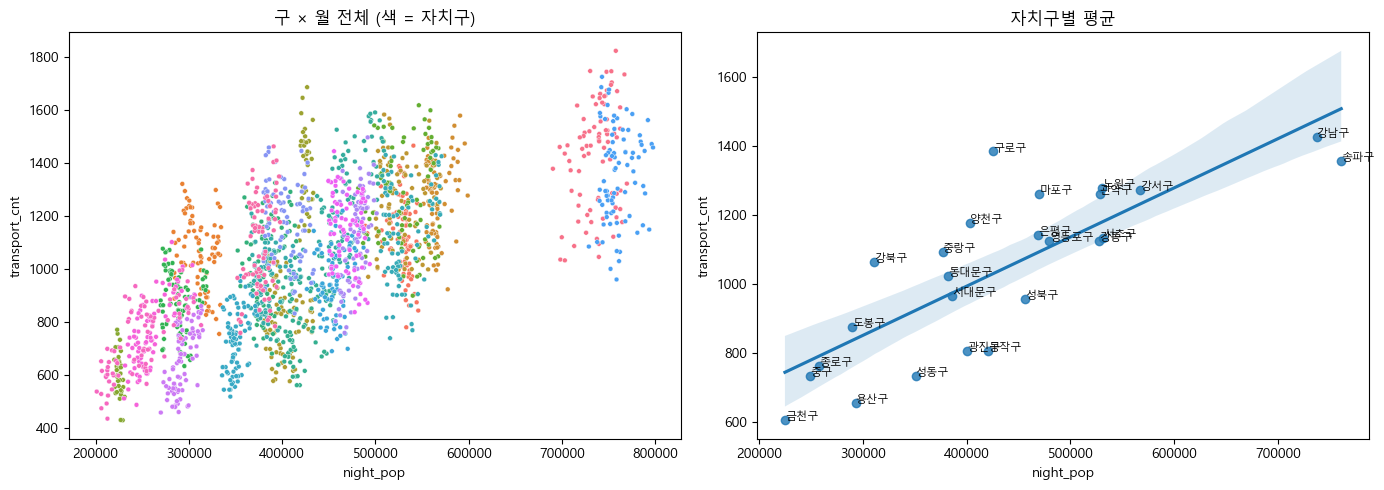

,전체_피어슨,전체_스피어만,자치구간,자치구내,자치구내_계절제거
night_pop,0.694,0.699,0.804,0.230,0.306
동일자치구행정동간이동인구수,0.644,0.656,0.777,0.005,0.017
일최소인구수,0.656,0.667,0.773,0.110,0.188
내국인생활인구수,0.660,0.686,0.762,0.195,0.273
total_pop,0.650,0.663,0.751,0.241,0.319
일최대인구수,0.599,0.623,0.681,0.315,0.385
day_pop,0.552,0.569,0.635,0.240,0.317
일최대이동인구수,0.407,0.331,0.452,0.275,0.349
서울외유입인구수,0.344,0.205,0.364,0.364,0.467
자치구간이동인구수,0.136,-0.016,0.140,0.314,0.392


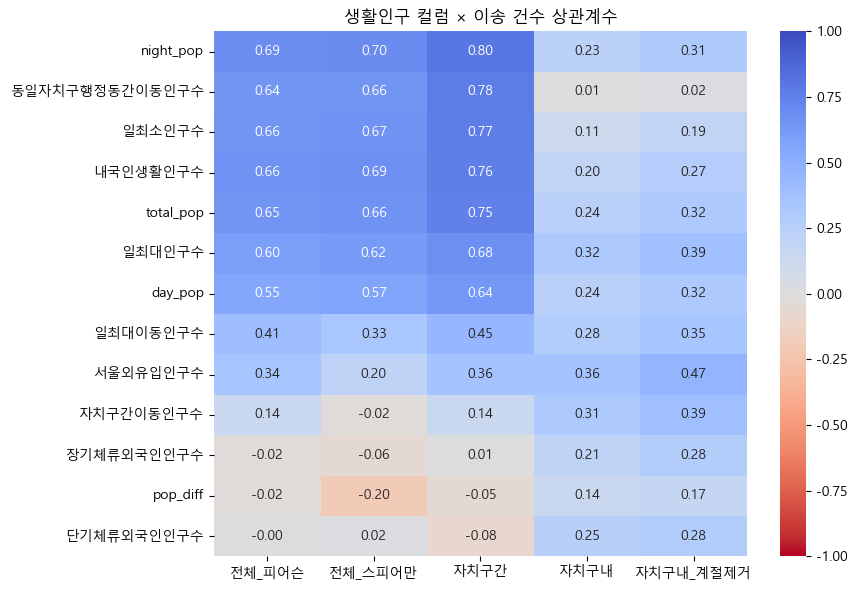

In [5]:
district_mean = rel.groupby('District')[POP_COLS + [target]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=rel, x='night_pop', y=target, hue='District', legend=False, s=12, ax=axes[0])
axes[0].set_title('구 × 월 전체 (색 = 자치구)')
sns.regplot(data=district_mean, x='night_pop', y=target, ax=axes[1])
for gu, row in district_mean.iterrows():
    axes[1].text(row['night_pop'], row[target], gu, fontsize=8)
axes[1].set_title('자치구별 평균')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_scatter.png', bbox_inches='tight')
plt.show()

within = rel.copy()
within_season = rel.copy()
for c in POP_COLS + [target]:
    within[c] = rel[c] - rel.groupby('District')[c].transform('mean')
    within_season[c] = rel[c] - rel.groupby(['District', '월'])[c].transform('mean')

rel_corr = pd.DataFrame({
    '전체_피어슨': rel[POP_COLS].corrwith(rel[target]),
    '전체_스피어만': rel[POP_COLS].corrwith(rel[target], method='spearman'),
    '자치구간': district_mean[POP_COLS].corrwith(district_mean[target]),
    '자치구내': within[POP_COLS].corrwith(within[target]),
    '자치구내_계절제거': within_season[POP_COLS].corrwith(within_season[target]),
}).round(3).sort_values('자치구간', ascending=False)
display(rel_corr)

plt.figure(figsize=(9, 6))
sns.heatmap(rel_corr, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.title('생활인구 컬럼 × 이송 건수 상관계수')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_corr_heatmap.png', bbox_inches='tight')
plt.show()

## 2-3. 대표 인구 컬럼 · 유의성 검정 · 인구 1만명당 이송률
- 대표 컬럼 : 자치구 간 상관이 가장 높은 컬럼
- `pearsonr` : 상관계수 + p-value, p-value ≤ 0.05 → 통계적으로 의미 있음
- 이송률 : 구별 월평균 이송 건수 ÷ 대표 인구 × 10,000
- 이송률 차이가 크면 → 인구만으로는 부족, 구마다 다른 "이송률" 정보 필요

대표 인구 컬럼 : night_pop
전체         r =  0.694, p-value = 0.0000, n = 1933
자치구간       r =  0.804, p-value = 0.0000, n = 25
자치구내       r =  0.230, p-value = 0.0000, n = 1933
자치구내_계절제거  r =  0.306, p-value = 0.0000, n = 1933

이송률 최고/최저 비율 : 1.91배


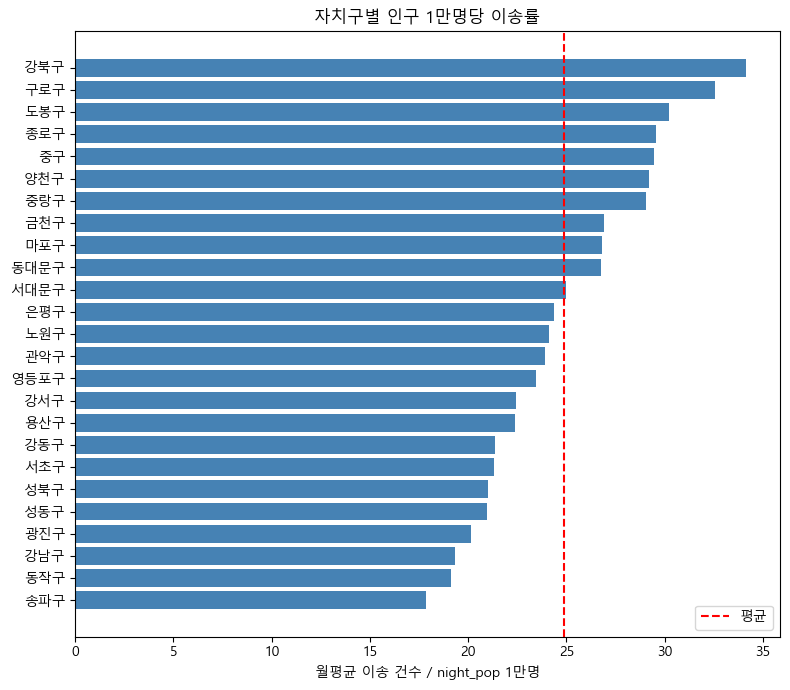

In [6]:
KEY_POP = rel_corr['자치구간'].idxmax()
print('대표 인구 컬럼 :', KEY_POP)

tests = {
    '전체': (rel[KEY_POP], rel[target]),
    '자치구간': (district_mean[KEY_POP], district_mean[target]),
    '자치구내': (within[KEY_POP], within[target]),
    '자치구내_계절제거': (within_season[KEY_POP], within_season[target]),
}
for name, (x, y) in tests.items():
    r, p = pearsonr(x, y)
    print(f'{name:10s} r = {r:6.3f}, p-value = {p:.4f}, n = {len(x)}')

district_rate = pd.DataFrame({'월평균_이송건수': district_mean[target], '월평균_인구': district_mean[KEY_POP]})
district_rate['인구1만명당_이송률'] = district_rate['월평균_이송건수'] / district_rate['월평균_인구'] * 10000
district_rate = district_rate.sort_values('인구1만명당_이송률')
rate_ratio = district_rate['인구1만명당_이송률'].max() / district_rate['인구1만명당_이송률'].min()
print(f'\n이송률 최고/최저 비율 : {rate_ratio:.2f}배')

plt.figure(figsize=(8, 7))
plt.barh(district_rate.index, district_rate['인구1만명당_이송률'], color='steelblue')
plt.axvline(district_rate['인구1만명당_이송률'].mean(), c='r', linestyle='--', label='평균')
plt.xlabel(f'월평균 이송 건수 / {KEY_POP} 1만명')
plt.title('자치구별 인구 1만명당 이송률')
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_district_rate.png', bbox_inches='tight')
plt.show()

## 2-4. 시계열 분해 · 시차
- `seasonal_decompose` : 실제값 = 추세(trend) + 계절성(seasonal) + 잔차(resid), `period=12`
- 같은 성분끼리 상관
  - 추세 : 장기적으로 같이 오르내리는가
  - 계절 : 계절 패턴이 같은 방향인가 (음수면 반대)
  - 잔차 : 갑작스러운 변화가 같이 나타나는가
- 준비 조건 : 날짜 인덱스 + 빈 달 없이 연속 (`asfreq('MS')` + 보간), 최소 24개월
- 표준화 비교 : (값 − 평균) / 표준편차 → 단위가 달라도 겹쳐 보기 가능
- 시차 : 이번 달 / 1·2·3개월 전 인구 중 어느 것이 이송과 가까운가 (`shift`)

[구 평균]


,구 평균
원본_상관,0.19
추세_상관,0.17
계절_상관,-0.40
잔차_상관,0.17


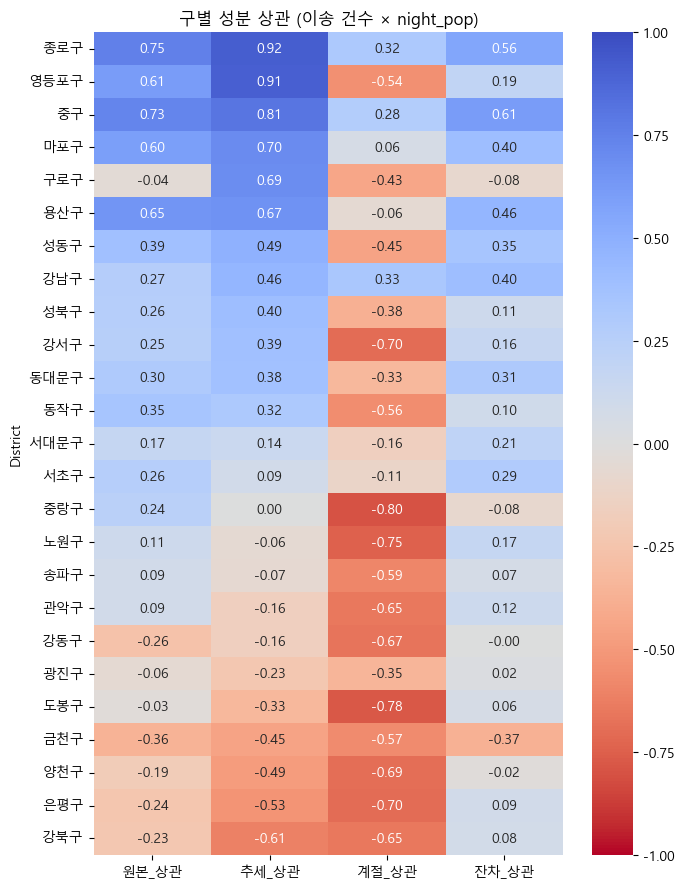

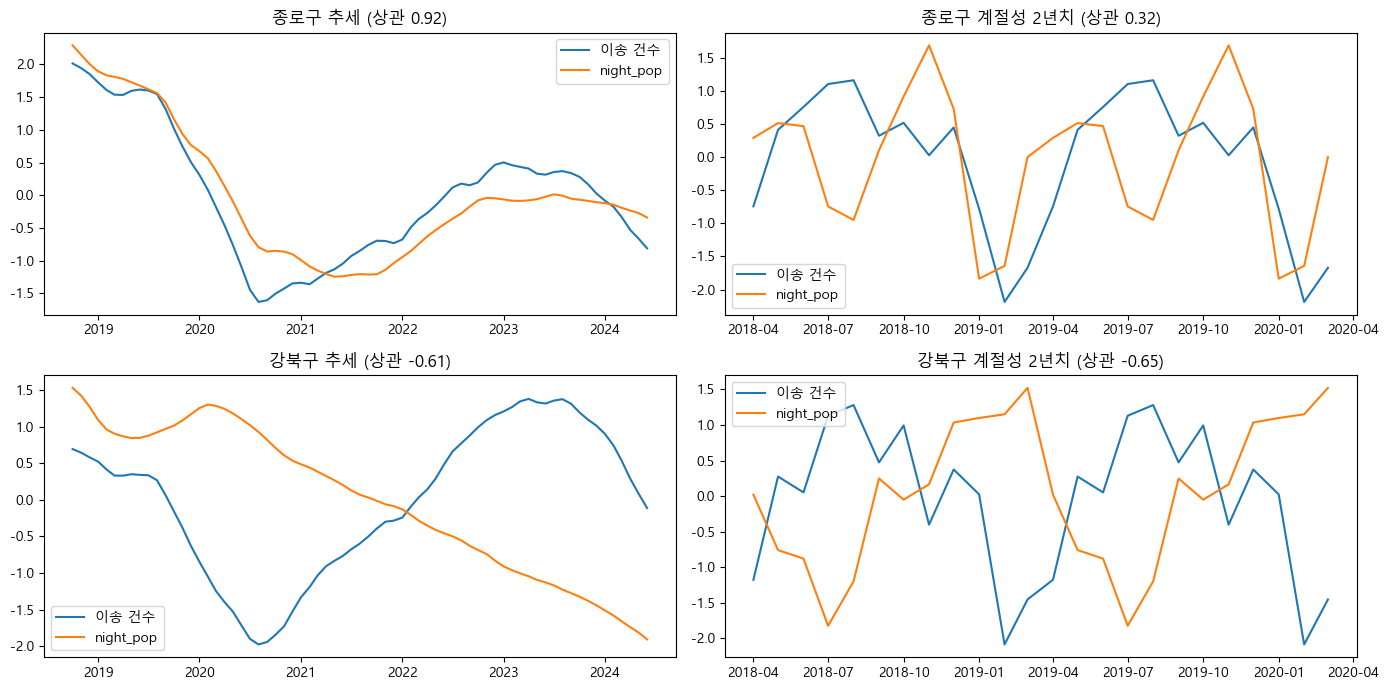

,transport_cnt,night_pop,이송_증감률(%),인구_증감률(%)
ds,,,,
2018,27430.0,10687556.0,NaN,NaN
2019,26035.0,10469265.0,-5.1,-2.0
2020,20650.0,10275724.0,-20.7,-1.8
2021,21597.0,9988877.0,4.6,-2.8
2022,27143.0,10641313.0,25.7,6.5
2023,28442.0,10663715.0,4.8,0.2
2024,23686.0,10562199.0,-16.7,-1.0


,시차(개월),상관계수
0,0,0.306
1,1,0.261
2,2,0.216
3,3,0.163


In [7]:
decomp_rows = []
decomp_result = {}
for gu, g in rel.groupby('District'):
    s = g.set_index('ds')[[target, KEY_POP]].asfreq('MS').interpolate()
    if len(s) < 24:
        print(f'[건너뜀] {gu} : 기간이 24개월 미만')
        continue
    rt = seasonal_decompose(s[target], period=12, model='additive')
    rp = seasonal_decompose(s[KEY_POP], period=12, model='additive')
    decomp_result[gu] = (rt, rp)
    decomp_rows.append({
        'District': gu,
        '원본_상관': s[target].corr(s[KEY_POP]),
        '추세_상관': rt.trend.corr(rp.trend),
        '계절_상관': rt.seasonal.corr(rp.seasonal),
        '잔차_상관': rt.resid.corr(rp.resid),
    })

decomp_corr = pd.DataFrame(decomp_rows).set_index('District').round(2).sort_values('추세_상관', ascending=False)
print('[구 평균]')
display(decomp_corr.mean().round(2).to_frame('구 평균'))

plt.figure(figsize=(7, 9))
sns.heatmap(decomp_corr, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.title(f'구별 성분 상관 (이송 건수 × {KEY_POP})')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_decompose_corr.png', bbox_inches='tight')
plt.show()


def zscore(s):
    return (s - s.mean()) / s.std()


# 추세 상관 최고 구 vs 최저 구
pick = [decomp_corr.index[0], decomp_corr.index[-1]]
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for i, gu in enumerate(pick):
    rt, rp = decomp_result[gu]
    axes[i, 0].plot(zscore(rt.trend), label='이송 건수')
    axes[i, 0].plot(zscore(rp.trend), label=KEY_POP)
    axes[i, 0].set_title(f'{gu} 추세 (상관 {decomp_corr.loc[gu, "추세_상관"]:.2f})')
    axes[i, 0].legend()
    axes[i, 1].plot(zscore(rt.seasonal)[:24], label='이송 건수')
    axes[i, 1].plot(zscore(rp.seasonal)[:24], label=KEY_POP)
    axes[i, 1].set_title(f'{gu} 계절성 2년치 (상관 {decomp_corr.loc[gu, "계절_상관"]:.2f})')
    axes[i, 1].legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_trend_compare.png', bbox_inches='tight')
plt.show()

# 연도별 서울 전체 흐름 : 인구 변화 없이 이송만 크게 변한 해가 있는지
city = rel.groupby('ds')[[target, KEY_POP]].sum()
yearly = city.groupby(city.index.year).mean()
yearly_change = (yearly.pct_change() * 100).round(1)
yearly_change.columns = ['이송_증감률(%)', '인구_증감률(%)']
display(pd.concat([yearly.round(0), yearly_change], axis=1))

# 시차 확인 (자치구 내, 계절 제거 값 기준)
lag_rows = []
for lag in [0, 1, 2, 3]:
    temp = within_season.copy()
    temp['pop_lag'] = temp.groupby('District')[KEY_POP].shift(lag)
    temp = temp.dropna(subset=['pop_lag'])
    lag_rows.append({'시차(개월)': lag, '상관계수': round(temp['pop_lag'].corr(temp[target]), 3)})
lag_table = pd.DataFrame(lag_rows)
display(lag_table)

---
# 3. 인구 특성 추가 효과 비교

**질문** : 생활인구를 넣으면 이송 건수 예측이 실제로 좋아지는가

## 3-1. 모델용 인구 특성 선택 · 인구 기반 특성 만들기
- 후보 : `전월_` 생활인구 컬럼 (예측 시점에 알 수 있는 값)
- 선택 기준 : 학습 기간 상관계수 |r| ≥ `POP_CORR_MIN`
- `구별_이송률` : 학습 기간만으로 계산한 "이송 건수 ÷ 전월 인구" 구별 평균 (타깃 인코딩과 같은 원리)
- `인구기반_예상` : 구별_이송률 × 전월 인구 → "인구로 본 기대 이송 건수"
- 모델에는 `인구기반_예상`만 사용 : `구별_이송률`은 구마다 고정값이라 `구_` 원-핫과 정보가 같음

In [8]:
pop_candidates = [c for c in full.columns
                  if c.startswith('전월_') and ('pop' in c or '인구' in c)]
train_rows = full[full['ds'] < valid_start]

pop_corr = train_rows[pop_candidates].corrwith(train_rows[target]).sort_values(key=abs, ascending=False)
pop_select = pd.DataFrame({'Pearson_r': pop_corr.round(4), '선택': pop_corr.abs() >= POP_CORR_MIN})
POP_FEATURES = pop_select.index[pop_select['선택']].tolist()
if not POP_FEATURES:
    POP_FEATURES = [pop_corr.index[0]]
display(pop_select)
print('\n선택된 인구 특성 :', POP_FEATURES)

KEY_POP_PREV = '전월_' + KEY_POP
if KEY_POP_PREV not in full.columns:
    KEY_POP_PREV = '전월_night_pop'
rate_map = (train_rows[target] / train_rows[KEY_POP_PREV]).groupby(train_rows['District']).mean()


def add_pop_rate(df):
    df = df.copy()
    df['구별_이송률'] = df['District'].map(rate_map)
    if KEY_POP_PREV in df.columns:
        df['인구기반_예상'] = df['구별_이송률'] * df[KEY_POP_PREV]
    return df


full = add_pop_rate(full)
future = add_pop_rate(future)

print(f'\n이송률 기준 인구 : {KEY_POP_PREV}')
print('인구 1만명당 이송 건수 (학습 기간, 상위 5개)')
display((rate_map * 10000).sort_values(ascending=False).head().round(1).to_frame('인구 1만명당 이송 건수'))

,Pearson_r,선택
전월_night_pop,0.6925,True
전월_내국인생활인구수,0.6586,True
전월_일최소인구수,0.6542,True
전월_동일자치구행정동간이동인구수,0.6487,True
전월_total_pop,0.6479,True
전월_일최대인구수,0.5971,True
전월_day_pop,0.5495,True
전월_일최대이동인구수,0.4068,True
전월_서울외유입인구수,0.3400,True
전월_자치구간이동인구수,0.1368,False



선택된 인구 특성 : ['전월_night_pop', '전월_내국인생활인구수', '전월_일최소인구수', '전월_동일자치구행정동간이동인구수', '전월_total_pop', '전월_일최대인구수', '전월_day_pop', '전월_일최대이동인구수', '전월_서울외유입인구수']

이송률 기준 인구 : 전월_night_pop
인구 1만명당 이송 건수 (학습 기간, 상위 5개)


,인구 1만명당 이송 건수
District,
강북구,34.3
구로구,32.6
도봉구,30.2
중구,29.4
종로구,29.4


## 3-2. 특성 조합 5가지 비교
- 모든 조합에 `구_`·`월_` 원-핫 포함
- A 계절 : 원-핫만
- B 계절+인구 : A + 선택된 인구 특성
- C 계절+인구+이송률 : B + 인구기반_예상
- D 계절+이송이력 : A + 전월·전년 동월 이송 건수 등
- E 전체 : D + 인구 특성 + 인구기반_예상
- 비교 포인트 : A→B→C (이송 기록 없을 때 인구 효과) / D→E (이송 기록 있을 때 추가 효과)
- 같은 행 비교 : 모든 조합에 필요한 값이 있는 행만 사용
- 모델 3종 : LinearRegression · RandomForest · GradientBoosting
- 기준선 : "이번 달 = 지난달" 그대로

In [9]:
HISTORY = [c for c in ['전월_transport_cnt', '전년동월_transport_cnt', '전년동월_y', '전년_인명갇힘', '전년_승강기사고']
           if c in full.columns]

FEATURE_SETS = {
    'A_계절': [],
    'B_계절+인구': POP_FEATURES,
    'C_계절+인구+이송률': POP_FEATURES + ['인구기반_예상'],
    'D_계절+이송이력': HISTORY,
    'E_전체': HISTORY + POP_FEATURES + ['인구기반_예상'],
}

all_cols = sorted(set(sum(FEATURE_SETS.values(), [])))
cmp_df = full.dropna(subset=all_cols + [target]).sort_values(['ds', 'District']).reset_index(drop=True)
cmp_train = cmp_df[cmp_df['ds'] < valid_start]
cmp_valid = cmp_df[(cmp_df['ds'] >= valid_start) & (cmp_df['ds'] < test_start)]
cmp_tv = cmp_df[cmp_df['ds'] < test_start]
cmp_test = cmp_df[cmp_df['ds'] >= test_start]
print(f'학습 {len(cmp_train)}행 / 검증 {len(cmp_valid)}행 / 평가 {len(cmp_test)}행')

cmp_rows = []
cmp_bundles = {}
for set_name, cols in FEATURE_SETS.items():
    for name in COMPARE_MODELS:
        b = fit_model(name, make_transport_X(cmp_train, cols), cmp_train[target], 'transport')
        v = evaluate(cmp_valid[target], predict(b, make_transport_X(cmp_valid, cols)))

        b = fit_model(name, make_transport_X(cmp_tv, cols), cmp_tv[target], 'transport')
        t = evaluate(cmp_test[target], predict(b, make_transport_X(cmp_test, cols)))
        cmp_bundles[(set_name, name)] = b

        cmp_rows.append({'특성조합': set_name, '모델': name, '검증_정확도(%)': v['정확도(%)'],
                         '평가_정확도(%)': t['정확도(%)'], '평가_R2': t['R2'], '평가_MAE': t['MAE']})

v = evaluate(cmp_valid[target], cmp_valid['전월_transport_cnt'])
t = evaluate(cmp_test[target], cmp_test['전월_transport_cnt'])
cmp_rows.append({'특성조합': '기준선(전월값)', '모델': '-', '검증_정확도(%)': v['정확도(%)'],
                 '평가_정확도(%)': t['정확도(%)'], '평가_R2': t['R2'], '평가_MAE': t['MAE']})

cmp_score = pd.DataFrame(cmp_rows)
display(cmp_score.round(3))

학습 1880행 / 검증 150행 / 평가 150행


,특성조합,모델,검증_정확도(%),평가_정확도(%),평가_R2,평가_MAE
0,A_계절,LinearRegression,84.391,88.963,0.704,101.273
1,A_계절,RandomForest,80.684,90.102,0.755,88.954
2,A_계절,GradientBoosting,82.957,88.917,0.730,97.715
3,B_계절+인구,LinearRegression,83.369,89.400,0.721,96.475
4,B_계절+인구,RandomForest,85.831,93.477,0.897,59.552
5,B_계절+인구,GradientBoosting,87.211,92.960,0.863,65.300
6,C_계절+인구+이송률,LinearRegression,83.292,89.348,0.718,96.969
7,C_계절+인구+이송률,RandomForest,87.402,93.572,0.890,60.045
8,C_계절+인구+이송률,GradientBoosting,88.034,92.900,0.862,66.025
9,D_계절+이송이력,LinearRegression,94.335,94.572,0.926,50.033


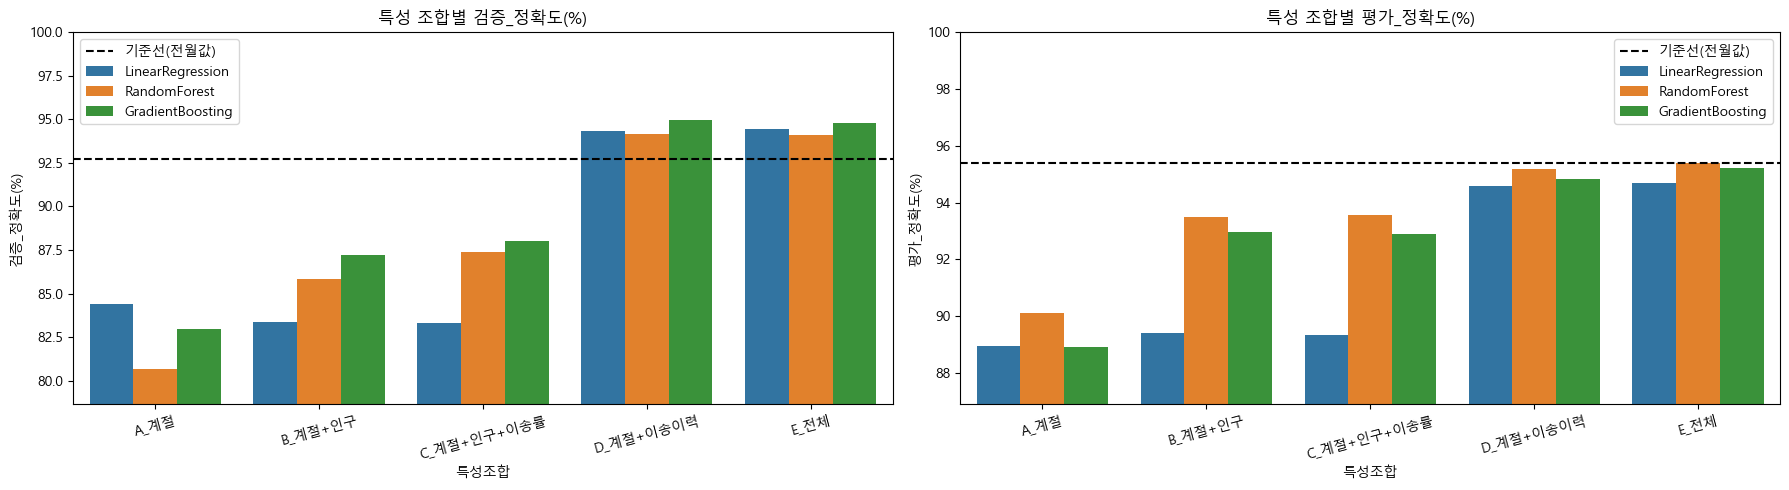

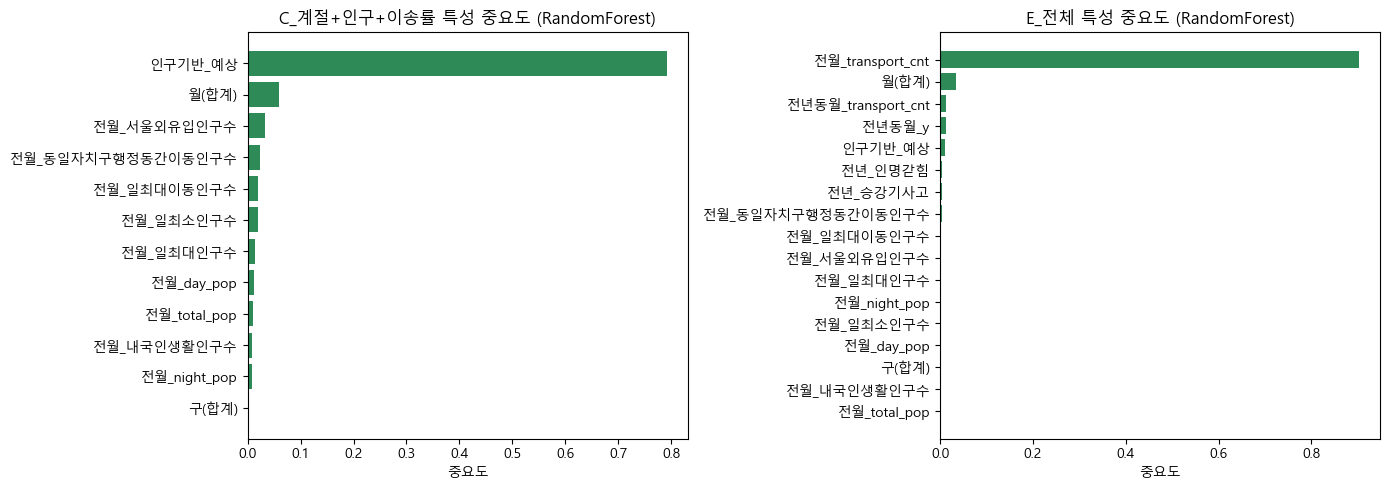

In [10]:
model_rows = cmp_score[cmp_score['모델'] != '-']
base_row = cmp_score[cmp_score['모델'] == '-'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, col in zip(axes, ['검증_정확도(%)', '평가_정확도(%)']):
    sns.barplot(data=model_rows, x='특성조합', y=col, hue='모델', ax=ax)
    ax.axhline(base_row[col], c='k', linestyle='--', label='기준선(전월값)')
    ax.set_ylim(cmp_score[col].min() - 2, 100)
    ax.set_title(f'특성 조합별 {col}')
    ax.tick_params(axis='x', rotation=15)
    ax.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_model_compare.png', bbox_inches='tight')
plt.show()

# 특성 중요도 : C(이송 기록 없음) vs E(전체)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, set_name in zip(axes, ['C_계절+인구+이송률', 'E_전체']):
    imp = group_importance(cmp_bundles[(set_name, 'RandomForest')], ['구_', '월_'])
    plot_importance(imp, f'{set_name} 특성 중요도 (RandomForest)', ax)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_feature_importance.png', bbox_inches='tight')
plt.show()

## 3-3. 메인 모델에 인구 특성을 넣을지 결정 · 저장
- 결정 기준 : **검증** 정확도에서 E가 D보다 높을 때만 추가 (평가 점수로 고르지 않음)
- 추가 조건 : 미래 입력(`transport_future.csv`)에도 그 값이 모두 있어야 함 → 없으면 미래 예측이 불가능
- 저장 : 분석 표 → `ml_result`, 인구 기반 특성을 붙인 데이터 → `ml_data/transport_pop_features.csv`

In [11]:
def best_valid(set_name):
    return cmp_score.loc[cmp_score['특성조합'] == set_name, '검증_정확도(%)'].max()


pop_gain = best_valid('E_전체') - best_valid('D_계절+이송이력')
add_cols = [c for c in POP_FEATURES + ['인구기반_예상'] if c not in num_features]
future_ok = all(c in future.columns and future[c].notna().all() for c in add_cols)

USE_POP = bool(add_cols) and pop_gain > 0 and future_ok
if USE_POP:
    num_features = num_features + add_cols
    print(f'인구 특성 추가 (검증 정확도 {pop_gain:+.3f}%p) :', add_cols)
elif pop_gain <= 0:
    print(f'검증 정확도 개선 없음 ({pop_gain:+.3f}%p) → 기존 특성 유지')
elif not future_ok:
    print('미래 입력에 인구 값이 없는 달이 있음 → 기존 특성 유지')
print('메인 모델 특성 :', num_features)

rel_corr.to_csv(RESULT_DIR / 'relation_corr_table.csv', encoding='utf-8-sig')
district_out = district_rate.join(decomp_corr).reset_index().rename(columns={'District': '지역구명'})
district_out.round(3).to_csv(RESULT_DIR / 'relation_district_rate.csv', index=False, encoding='utf-8-sig')
pop_select.to_csv(RESULT_DIR / 'relation_pop_feature_select.csv', encoding='utf-8-sig')
cmp_score.to_csv(RESULT_DIR / 'relation_model_compare.csv', index=False, encoding='utf-8-sig')

save_cols = [c for c in full.columns if c != target] + [target]
full[save_cols].to_csv(ML_DATA_DIR / 'transport_pop_features.csv', index=False, encoding='utf-8-sig')
print('연관성 분석 결과 저장 완료')

검증 정확도 개선 없음 (-0.177%p) → 기존 특성 유지
메인 모델 특성 : ['전월_transport_cnt', '전년동월_transport_cnt', '전월_night_pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '전월_서울외유입인구수']
연관성 분석 결과 저장 완료


---
# 4. 이송 건수 예측 (자치구 × 월)

## 4-0. 달력 특성 만들기
- 필요한 이유 : `월_` 원-핫은 "몇 월인가"만 알려 줌 → 같은 월이라도 해마다 다른 달력 차이는 모름
  - 예) 설 연휴가 1월인 해 vs 2월인 해, 윤년 2월(29일), 주말이 5번인 달
- 특성 4종
  - `일수` : 그 달의 날짜 수 (28~31)
  - `주말수` : 토·일 수
  - `평일공휴일수` : 평일에 걸린 공휴일 수 (주말과 겹치는 공휴일은 이미 주말수에 포함)
  - `명절연휴일수` : 설·추석 연휴(전날·당일·다음날)가 그 달에 걸린 날 수
- 공휴일 표 : 양력 공휴일 + 음력 공휴일(설날·추석·석가탄신일) 날짜를 연도별로 직접 입력
  - 미포함 : 대체공휴일, 선거일, 임시공휴일 → 월 단위라 영향 작음
  - 표에 없는 연도 : 양력 공휴일만 계산하고 안내 문구 출력 → 필요하면 `LUNAR_HOLIDAYS`에 한 줄 추가
- 미래 예측 입력(`transport_future.csv`)에도 같은 방식으로 계산 → 미래 값이 항상 있음

In [12]:
FIXED_HOLIDAYS = ['01-01', '03-01', '05-05', '06-06', '08-15', '10-03', '12-25']

# 연도: (설날, 추석, 석가탄신일) — 음력이라 해마다 날짜가 다름
LUNAR_HOLIDAYS = {
    2005: ('2005-02-09', '2005-09-18', '2005-05-15'),
    2006: ('2006-01-29', '2006-10-06', '2006-05-05'),
    2007: ('2007-02-18', '2007-09-25', '2007-05-24'),
    2008: ('2008-02-07', '2008-09-14', '2008-05-12'),
    2009: ('2009-01-26', '2009-10-03', '2009-05-02'),
    2010: ('2010-02-14', '2010-09-22', '2010-05-21'),
    2011: ('2011-02-03', '2011-09-12', '2011-05-10'),
    2012: ('2012-01-23', '2012-09-30', '2012-05-28'),
    2013: ('2013-02-10', '2013-09-19', '2013-05-17'),
    2014: ('2014-01-31', '2014-09-08', '2014-05-06'),
    2015: ('2015-02-19', '2015-09-27', '2015-05-25'),
    2016: ('2016-02-08', '2016-09-15', '2016-05-14'),
    2017: ('2017-01-28', '2017-10-04', '2017-05-03'),
    2018: ('2018-02-16', '2018-09-24', '2018-05-22'),
    2019: ('2019-02-05', '2019-09-13', '2019-05-12'),
    2020: ('2020-01-25', '2020-10-01', '2020-04-30'),
    2021: ('2021-02-12', '2021-09-21', '2021-05-19'),
    2022: ('2022-02-01', '2022-09-10', '2022-05-08'),
    2023: ('2023-01-22', '2023-09-29', '2023-05-27'),
    2024: ('2024-02-10', '2024-09-17', '2024-05-15'),
    2025: ('2025-01-29', '2025-10-06', '2025-05-05'),
    2026: ('2026-02-17', '2026-09-25', '2026-05-24'),
    2027: ('2027-02-07', '2027-09-15', '2027-05-13'),
}
CAL_FEATURES = ['일수', '주말수', '평일공휴일수', '명절연휴일수']


def holiday_dates(year):
    # 반환 : (전체 공휴일, 명절 연휴)
    days = [pd.Timestamp(f'{year}-{md}') for md in FIXED_HOLIDAYS]
    if year <= 2007:
        days.append(pd.Timestamp(f'{year}-07-17'))   # 제헌절 (2008년부터 공휴일 제외)
    if year >= 2013:
        days.append(pd.Timestamp(f'{year}-10-09'))   # 한글날 (2013년부터 다시 공휴일)
    festive = []
    if year in LUNAR_HOLIDAYS:
        seol, chuseok, buddha = [pd.Timestamp(d) for d in LUNAR_HOLIDAYS[year]]
        festive = [d + pd.Timedelta(days=k) for d in (seol, chuseok) for k in (-1, 0, 1)]
        days = days + festive + [buddha]
    return set(days), set(festive)


def add_calendar(df):
    df = df.drop(columns=CAL_FEATURES, errors='ignore')
    rows = {}
    for m in sorted(df['ds'].unique()):
        m = pd.Timestamp(m)
        holi, festive = holiday_dates(m.year)
        days = pd.date_range(m, m + pd.offsets.MonthEnd(0))
        weekend = days.dayofweek >= 5
        rows[m] = {
            '일수': len(days),
            '주말수': int(weekend.sum()),
            '평일공휴일수': sum(d in holi and not w for d, w in zip(days, weekend)),
            '명절연휴일수': sum(d in festive for d in days),
        }
    cal = pd.DataFrame.from_dict(rows, orient='index')
    return df.join(cal, on='ds'), cal


full, cal_table = add_calendar(full)
future, cal_future = add_calendar(future)

no_lunar = sorted({d.year for d in list(cal_table.index) + list(cal_future.index)} - set(LUNAR_HOLIDAYS))
if no_lunar:
    print('[주의] 음력 공휴일 표에 없는 연도 (양력 공휴일만 계산) :', no_lunar)

cal_all = pd.concat([cal_table, cal_future]).sort_index()
cal_all = cal_all[~cal_all.index.duplicated()]
cal_all.index.name = 'ds'
cal_all.to_csv(RESULT_DIR / 'transport_calendar.csv', encoding='utf-8-sig')

print('달력 특성 예시 (최근 12개월)')
display(cal_table.tail(12))

달력 특성 예시 (최근 12개월)


,일수,주말수,평일공휴일수,명절연휴일수
2025-01-01,31,8,4,3
2025-02-01,28,8,0,0
2025-03-01,31,10,0,0
2025-04-01,30,8,0,0
2025-05-01,31,9,1,0
2025-06-01,30,9,1,0
2025-07-01,31,8,0,0
2025-08-01,31,10,1,0
2025-09-01,30,8,0,0
2025-10-01,31,8,4,3


## 4-1. 학습 데이터 · 3단계 분할
- 빈 값이 있는 행 제거 : 빈 값을 임의 값으로 채우지 않음
- 분할 날짜 : 1장에서 정한 `valid_start`, `test_start` 그대로 사용
- 이 단계의 `num_features`에는 달력 특성이 아직 없음 → 4-1-2 실험 결과로 추가 여부 결정

In [13]:
data = full.dropna(subset=num_features + [target]).sort_values(['ds', 'District']).reset_index(drop=True)


def make_X(df):
    return make_transport_X(df, num_features)


train = data[data['ds'] < valid_start].reset_index(drop=True)
valid = data[(data['ds'] >= valid_start) & (data['ds'] < test_start)].reset_index(drop=True)
train_valid = data[data['ds'] < test_start].reset_index(drop=True)
test = data[data['ds'] >= test_start].reset_index(drop=True)

print(f'전체 {len(full)}행 -> 학습 가능 {len(data)}행, 입력 컬럼 {make_X(train).shape[1]}개')
for name, part in [('학습', train), ('검증', valid), ('평가', test)]:
    print(f'{name} : {len(part)}행 ({part["ds"].min():%Y-%m} ~ {part["ds"].max():%Y-%m})')
print('행 수가 적은 구 :', data.groupby('District').size().nsmallest(4).to_dict())

전체 2564행 -> 학습 가능 2180행, 입력 컬럼 45개
학습 : 1880행 (2018-05 ~ 2024-12)
검증 : 150행 (2025-01 ~ 2025-06)
평가 : 150행 (2025-07 ~ 2025-12)
행 수가 적은 구 : {'구로구': 35, '금천구': 35, '광진구': 89, '성동구': 89}


## 4-1-1. 이송 예측 공통 함수
- `fit_transport` : 모델 학습 + 사용한 특성 목록·증감량 여부를 묶음에 함께 저장
  - 저장해 두는 이유 : 불러온 모델이 어떤 입력·방식으로 학습됐는지 스스로 알게
- **증감량 예측** (`diff_target=True`)
  - 정답 : 이번 달 − 지난달 (`전월_transport_cnt`)
  - 복원 : 예측 증감량 + 지난달 값 = 예측 이송 건수 (`predict_count`)
  - 원리 : 증감량은 해마다 비슷한 범위 → 트리 모델의 "학습 범위 밖 값 예측 불가" 약점 완화
  - 기준선과의 관계 : 증감량 0 예측 = 기준선(마지막 달 유지) → 모델은 기준선에서 얼마나 움직일지만 학습
- `predict_months` : 6개월 재귀 예측 (예측값 → 다음 달 `전월_transport_cnt`)
- `score_transport` : 1개월 · 6개월 점수 / `baseline_transport` : 기준선 점수

In [14]:
def fit_transport(name, df, features, diff_target):
    y = df[target] - df['전월_transport_cnt'] if diff_target else df[target]
    bundle = fit_model(name, make_transport_X(df, features), y, 'transport')
    bundle.update({'features': list(features), 'diff_target': diff_target})
    return bundle


def predict_count(bundle, df):
    pred = predict(bundle, make_transport_X(df, bundle['features']))
    if bundle.get('diff_target'):
        pred = pred + df['전월_transport_cnt'].values
    return pred


def predict_months(bundle, rows):
    # 한 달씩 예측하고, 예측값을 다음 달 '전월_transport_cnt'로 넣기
    rows = rows.sort_values(['ds', 'District']).reset_index(drop=True)
    parts = []
    prev = None
    for m in sorted(rows['ds'].unique()):
        part = rows[rows['ds'] == m].copy()
        if prev is not None:
            part['전월_transport_cnt'] = part['District'].map(prev).fillna(part['전월_transport_cnt'])
        part = part.dropna(subset=bundle['features']).reset_index(drop=True)
        part['예측'] = predict_count(bundle, part)
        prev = part.set_index('District')['예측']
        parts.append(part)
    return pd.concat(parts, ignore_index=True)


def score_transport(bundle, rows):
    one = evaluate(rows[target], predict_count(bundle, rows))
    rec = predict_months(bundle, rows)
    six = evaluate(rec[target], rec['예측'])
    return one, six, rec


def baseline_transport(rows):
    start = rows['ds'].min()
    last_value = full[full['ds'] < start].dropna(subset=[target]).sort_values('ds').groupby('District')[target].last()
    return {
        '기준선(마지막 달 유지)': (evaluate(rows[target], rows['전월_transport_cnt']),
                              evaluate(rows[target], rows['District'].map(last_value))),
        '기준선(전년 동월)': (evaluate(rows[target], rows['전년동월_transport_cnt']),
                          evaluate(rows[target], rows['전년동월_transport_cnt'])),
    }

## 4-1-2. 정확도 개선 실험 : 달력 특성 · 증감량 예측
- 설정 4가지
  - 기본 : 지금까지의 방식
  - 달력 : 기본 + 달력 특성 4종
  - 증감량 : 정답을 증감량으로 변경
  - 달력+증감량 : 둘 다 적용
- 실험 모델 : Ridge · GradientBoosting · RandomForest · 앙상블 (DNN은 시간이 오래 걸려 제외)
- 점수 : **학습 → 검증**만 사용 (평가 기간은 건드리지 않음)
- 결정 기준 : 설정별 최고 검증 6개월 정확도가 가장 높은 설정 채택
  - 기본보다 `IMPROVE_MIN`%p 이상 좋아야 채택 → 우연한 작은 차이로 바꾸지 않게
- 결정된 설정이 4-2 이후(모델 비교 · 최종 모델 · 미래 예측)에 자동 적용

기본       완료
달력       완료
증감량      완료
달력+증감량   완료


설정,기본,달력,증감량,달력+증감량
모델,,,,
Ensemble(GB+Ridge),93.885,94.612,94.226,94.470
GradientBoosting,93.426,94.354,93.571,91.747
RandomForest,92.497,92.510,93.663,87.228
Ridge,93.089,92.734,93.128,92.790


,설정별 최고 검증 6개월 정확도(%)
설정,
기본,93.885
달력,94.612
증감량,94.226
달력+증감량,94.470


채택 설정 : 달력 (달력 특성 True, 증감량 예측 False, 기본 대비 +0.727%p)
메인 모델 특성 : ['전월_transport_cnt', '전년동월_transport_cnt', '전월_night_pop', '전월_동일자치구행정동간이동인구수', '전월_일최대인구수', '전년_인명갇힘', '전년_승강기사고', '전월_서울외유입인구수', '일수', '주말수', '평일공휴일수', '명절연휴일수']


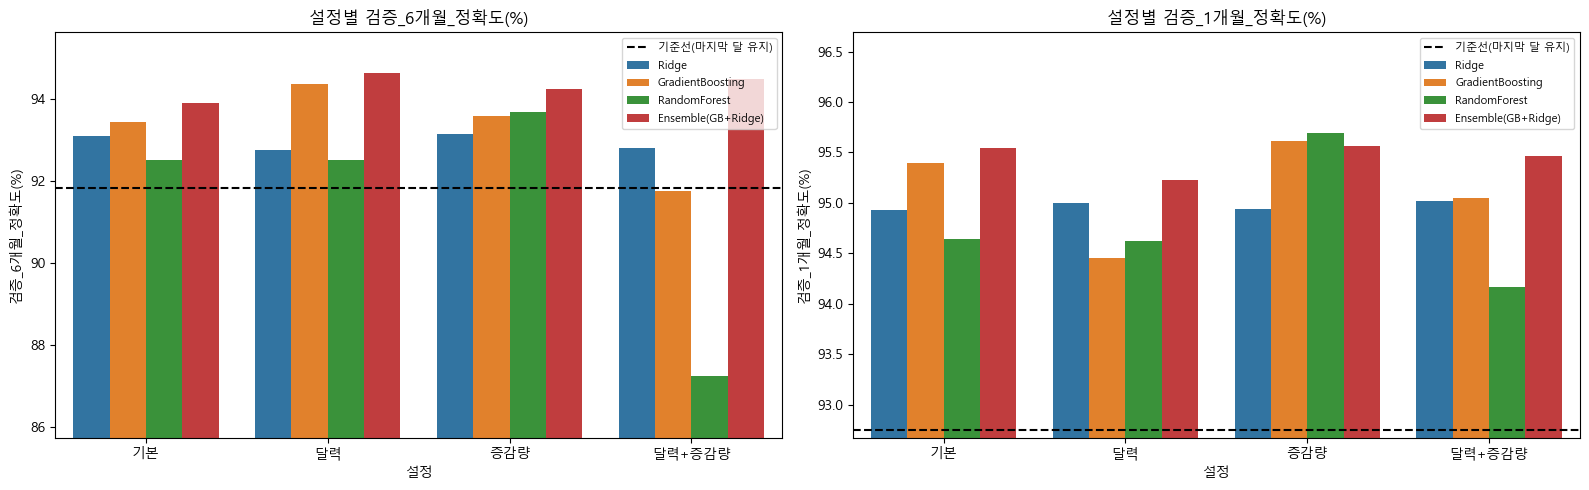

In [15]:
IMPROVE_MIN = 0.10   # 기본 대비 최소 개선 폭 (%p)
EXP_MODELS = ['Ridge', 'GradientBoosting', 'RandomForest', ENSEMBLE_NAME]
EXP_SETTINGS = {
    '기본': (False, False),        # (달력 특성, 증감량 예측)
    '달력': (True, False),
    '증감량': (False, True),
    '달력+증감량': (True, True),
}

base_valid = baseline_transport(valid)['기준선(마지막 달 유지)']
base_valid_one, base_valid_six = base_valid[0]['정확도(%)'], base_valid[1]['정확도(%)']

exp_rows = []
for set_name, (use_cal, use_diff) in EXP_SETTINGS.items():
    cols = num_features + (CAL_FEATURES if use_cal else [])
    for name in EXP_MODELS:
        b = fit_transport(name, train, cols, use_diff)
        one, six, _ = score_transport(b, valid)
        exp_rows.append({'설정': set_name, '모델': name,
                         '검증_6개월_정확도(%)': six['정확도(%)'], '검증_6개월_MAE': six['MAE'],
                         '검증_1개월_정확도(%)': one['정확도(%)'], '검증_1개월_MAE': one['MAE']})
    print(f'{set_name:8s} 완료')

exp_df = pd.DataFrame(exp_rows)
exp_df.round(3).to_csv(RESULT_DIR / 'transport_improve_experiment.csv', index=False, encoding='utf-8-sig')

# 설정 × 모델 표 (검증 6개월 정확도)
exp_table = exp_df.pivot(index='모델', columns='설정', values='검증_6개월_정확도(%)')[list(EXP_SETTINGS)]
display(exp_table.round(3))

best_by_set = exp_df.groupby('설정')['검증_6개월_정확도(%)'].max()[list(EXP_SETTINGS)]
display(best_by_set.round(3).to_frame('설정별 최고 검증 6개월 정확도(%)'))

best_set = best_by_set.idxmax()
gain = best_by_set[best_set] - best_by_set['기본']
if best_set != '기본' and gain < IMPROVE_MIN:
    print(f'최고 설정 {best_set} (+{gain:.3f}%p) → 개선 폭이 {IMPROVE_MIN}%p 미만이라 기본 유지')
    best_set = '기본'
USE_CALENDAR, USE_DIFF_TARGET = EXP_SETTINGS[best_set]
if USE_CALENDAR:
    num_features = num_features + CAL_FEATURES
print(f'채택 설정 : {best_set} (달력 특성 {USE_CALENDAR}, 증감량 예측 {USE_DIFF_TARGET}, 기본 대비 {gain:+.3f}%p)')
print('메인 모델 특성 :', num_features)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col in zip(axes, ['검증_6개월_정확도(%)', '검증_1개월_정확도(%)']):
    sns.barplot(data=exp_df, x='설정', y=col, hue='모델', order=list(EXP_SETTINGS), ax=ax)
    base = base_valid_one if '1개월' in col else base_valid_six
    ax.axhline(base, c='k', linestyle='--', label='기준선(마지막 달 유지)')
    ax.set_ylim(exp_df[col].min() - 1.5, min(100, exp_df[col].max() + 1))
    ax.set_title(f'설정별 {col}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_improve_experiment.png', bbox_inches='tight')
plt.show()

## 4-2. 모델 6종 + 앙상블 비교
- **1개월 예측** : 실제 지난달 값을 알고 다음 달만 예측
- **6개월 연속 예측** : 기간 시작 전 달까지만 알고 차례로 예측 (재귀 예측)
  - 이번 달 예측값 → 다음 달의 `전월_transport_cnt`로 사용
- **앙상블 `Ensemble(GB+Ridge)`** : GradientBoosting 예측과 Ridge 예측의 평균
  - 원리 : 두 모델이 틀리는 방향이 다르면 평균에서 오차가 서로 상쇄
  - 역할 분담 : GradientBoosting = 구·월 조합 효과 / Ridge = 직선 관계, 학습 범위 밖 추세
- 진행 순서
  1. 학습 데이터로 학습 → 검증 점수 (1개월 · 6개월)
  2. 학습+검증 데이터로 다시 학습 → 평가 점수 (1개월 · 6개월)
  3. 최고 모델 = **검증** 6개월 정확도 1위 (앙상블도 같은 기준으로 경쟁)
- 기준선 : 마지막 달 유지 · 전년 동월 (모델이 이보다 나아야 의미 있음)
- 입력 · 정답 방식 : 4-1-2에서 채택된 설정 (`num_features`, `USE_DIFF_TARGET`)

In [16]:
scores = []
detail_rows = []
bundles = {}
rec_preds = {}
valid_recs = {}


def add_detail(model, part, one, six):
    # 성능 평가표용 : 구간(검증/평가) × 방식(1개월/6개월) 한 줄씩
    for how, s in [('1개월', one), ('6개월', six)]:
        detail_rows.append({'모델': model, '구간': part, '방식': how, **s})


for name in TRANSPORT_MODELS:
    b_train = fit_transport(name, train, num_features, USE_DIFF_TARGET)
    v_one, v_six, v_rec = score_transport(b_train, valid)

    b_tv = fit_transport(name, train_valid, num_features, USE_DIFF_TARGET)
    t_one, t_six, t_rec = score_transport(b_tv, test)
    bundles[name] = b_tv
    rec_preds[name] = t_rec
    valid_recs[name] = v_rec

    add_detail(name, '검증', v_one, v_six)
    add_detail(name, '평가', t_one, t_six)
    scores.append({'모델': name, '검증_6개월_정확도(%)': v_six['정확도(%)'],
                   '평가_6개월_정확도(%)': t_six['정확도(%)'], '평가_6개월_MAE': t_six['MAE'],
                   '평가_1개월_정확도(%)': t_one['정확도(%)'], '평가_1개월_R2': t_one['R2']})
    print(f'{name:18s} 완료')

base_v = baseline_transport(valid)
base_t = baseline_transport(test)
for bname in base_t:
    add_detail(bname, '검증', base_v[bname][0], base_v[bname][1])
    add_detail(bname, '평가', base_t[bname][0], base_t[bname][1])
    scores.append({'모델': bname, '검증_6개월_정확도(%)': base_v[bname][1]['정확도(%)'],
                   '평가_6개월_정확도(%)': base_t[bname][1]['정확도(%)'], '평가_6개월_MAE': base_t[bname][1]['MAE'],
                   '평가_1개월_정확도(%)': base_t[bname][0]['정확도(%)'], '평가_1개월_R2': base_t[bname][0]['R2']})

score_df = pd.DataFrame(scores).sort_values('검증_6개월_정확도(%)', ascending=False).reset_index(drop=True)
score_df.to_csv(RESULT_DIR / 'transport_model_scores.csv', index=False, encoding='utf-8-sig')
display(score_df.round(3))

best_name = score_df[score_df['모델'].isin(TRANSPORT_MODELS)].iloc[0]['모델']
best_rec = rec_preds[best_name]
print('\n최고 모델 (검증 6개월 기준) :', best_name)

LinearRegression   완료
Ridge              완료
DecisionTree       완료
RandomForest       완료
GradientBoosting   완료
DNN                완료
Ensemble(GB+Ridge) 완료


,모델,검증_6개월_정확도(%),평가_6개월_정확도(%),평가_6개월_MAE,평가_1개월_정확도(%),평가_1개월_R2
0,Ensemble(GB+Ridge),94.612,94.593,51.762,94.621,0.923
1,GradientBoosting,94.354,93.267,62.062,95.002,0.934
2,LinearRegression,92.778,87.872,111.230,92.187,0.835
3,Ridge,92.734,94.271,54.196,93.595,0.892
4,RandomForest,92.510,93.984,54.684,95.600,0.944
5,기준선(마지막 달 유지),91.819,93.252,66.353,95.409,0.932
6,DecisionTree,91.449,92.760,66.464,95.304,0.936
7,DNN,88.287,91.671,76.234,93.357,0.893
8,기준선(전년 동월),87.482,90.680,90.853,90.680,0.775



최고 모델 (검증 6개월 기준) : Ensemble(GB+Ridge)


## 4-2-1. 모델별 성능 평가표 (scoring)
- 평가 단위 : 모델 × 구간(검증 · 평가) × 방식(1개월 · 6개월)
- 지표 4종
  - 정확도(%) : (1 − MAPE) × 100, 평균적으로 몇 % 차이 나는지의 반대
  - R2 : 실제 변동을 얼마나 설명하는지 (1에 가까울수록 좋음, sklearn `model.score()` 기본값과 같음)
  - MAE : 평균 몇 건 틀리는지 (건 단위)
  - RMSE : 크게 틀린 달에 벌점을 더 주는 오차 (MAE보다 많이 크면 가끔 크게 틀림)
- 기준선 대비 MAE 개선율(%) : (기준선 MAE − 모델 MAE) ÷ 기준선 MAE × 100
  - 기준선 = 마지막 달 유지, 양수면 기준선보다 나음
- 주의 : 모델 고르기는 **검증** 결과만, 평가 결과는 보고용


[검증 · 6개월 예측]


,모델,정확도(%),R2,MAE,RMSE,기준선대비_MAE_개선율(%)
0,Ensemble(GB+Ridge),94.612,0.939,43.662,52.231,33.286
1,GradientBoosting,94.354,0.922,46.518,59.026,28.922
2,LinearRegression,92.778,0.872,59.770,75.555,8.673
3,Ridge,92.734,0.871,60.113,75.891,8.150
4,RandomForest,92.510,0.888,57.090,70.811,12.769
5,기준선(마지막 달 유지),91.819,0.845,65.447,83.341,0.000
6,DecisionTree,91.449,0.832,68.617,86.838,-4.844
7,DNN,88.287,0.660,98.153,123.353,-49.974
8,기준선(전년 동월),87.482,0.614,104.700,131.515,-59.978



[검증 · 1개월 예측]


,모델,정확도(%),R2,MAE,RMSE,기준선대비_MAE_개선율(%)
0,Ensemble(GB+Ridge),95.231,0.942,40.413,50.882,34.571
1,LinearRegression,95.033,0.943,40.628,50.314,34.223
2,Ridge,95.001,0.943,40.784,50.446,33.972
3,RandomForest,94.626,0.931,44.990,55.561,27.161
4,GradientBoosting,94.454,0.913,47.620,62.527,22.903
5,DecisionTree,93.766,0.906,52.462,64.784,15.065
6,DNN,92.966,0.885,58.501,71.604,5.287
7,기준선(마지막 달 유지),92.743,0.857,61.767,80.152,0.000
8,기준선(전년 동월),87.482,0.614,104.700,131.515,-69.509



[평가 · 6개월 예측]


,모델,정확도(%),R2,MAE,RMSE,기준선대비_MAE_개선율(%)
0,Ensemble(GB+Ridge),94.593,0.916,51.762,65.544,21.991
1,Ridge,94.271,0.913,54.196,66.448,18.322
2,RandomForest,93.984,0.905,54.684,69.736,17.587
3,GradientBoosting,93.267,0.882,62.062,77.503,6.467
4,기준선(마지막 달 유지),93.252,0.862,66.353,83.830,0.000
5,DecisionTree,92.760,0.860,66.464,84.621,-0.167
6,DNN,91.671,0.833,76.234,92.205,-14.891
7,기준선(전년 동월),90.680,0.775,90.853,107.057,-36.924
8,LinearRegression,87.872,0.372,111.230,178.924,-67.633



[평가 · 1개월 예측]


,모델,정확도(%),R2,MAE,RMSE,기준선대비_MAE_개선율(%)
0,RandomForest,95.600,0.944,41.448,53.246,5.628
1,기준선(마지막 달 유지),95.409,0.932,43.920,58.773,0.000
2,DecisionTree,95.304,0.936,44.020,56.989,-0.227
3,GradientBoosting,95.002,0.934,47.021,57.837,-7.060
4,Ensemble(GB+Ridge),94.621,0.923,50.323,62.760,-14.579
5,Ridge,93.595,0.892,58.919,74.237,-34.151
6,DNN,93.357,0.893,61.489,73.749,-40.002
7,LinearRegression,92.187,0.835,72.111,91.667,-64.188
8,기준선(전년 동월),90.680,0.775,90.853,107.057,-106.861


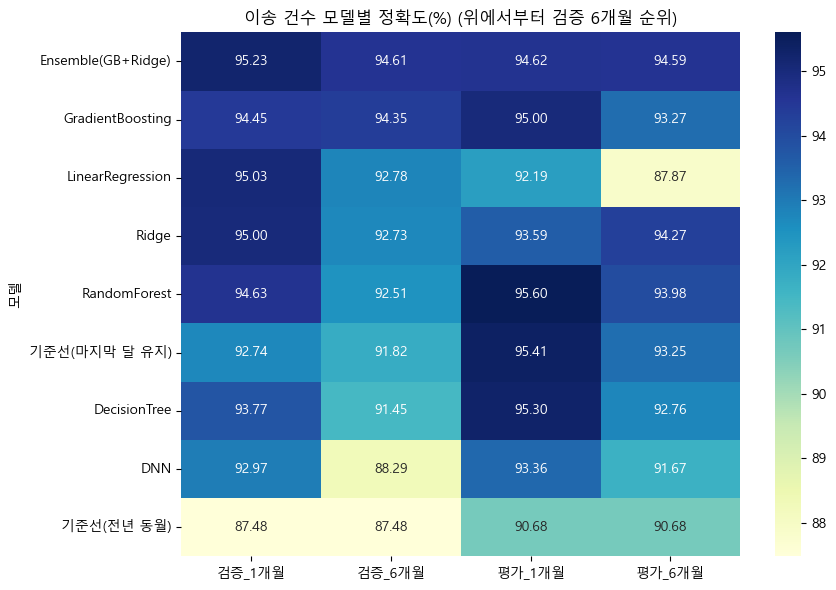

In [17]:
detail = pd.DataFrame(detail_rows)

# 같은 구간·방식의 기준선(마지막 달 유지) MAE와 비교
base_mae = detail[detail['모델'] == '기준선(마지막 달 유지)'].set_index(['구간', '방식'])['MAE']
detail['기준선대비_MAE_개선율(%)'] = [
    (base_mae[(p, h)] - m) / base_mae[(p, h)] * 100
    for p, h, m in zip(detail['구간'], detail['방식'], detail['MAE'])
]
detail.round(3).to_csv(RESULT_DIR / 'transport_model_scores_detail.csv', index=False, encoding='utf-8-sig')

for part in ['검증', '평가']:
    for how in ['6개월', '1개월']:
        table = detail[(detail['구간'] == part) & (detail['방식'] == how)]
        table = table.drop(columns=['구간', '방식']).sort_values('정확도(%)', ascending=False)
        print(f'\n[{part} · {how} 예측]')
        display(table.round(3).reset_index(drop=True))

# 정확도 한눈에 보기
acc_map = detail.pivot_table(index='모델', columns=['구간', '방식'], values='정확도(%)')
acc_map = acc_map[[('검증', '1개월'), ('검증', '6개월'), ('평가', '1개월'), ('평가', '6개월')]]
acc_map = acc_map.sort_values(('검증', '6개월'), ascending=False)
acc_map.columns = [f'{p}_{h}' for p, h in acc_map.columns]

plt.figure(figsize=(9, 6))
sns.heatmap(acc_map, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('이송 건수 모델별 정확도(%) (위에서부터 검증 6개월 순위)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_model_scores_detail.png', bbox_inches='tight')
plt.show()

## 4-2-2. 앙상블 효과 확인
- 비교 대상 : 앙상블 vs GradientBoosting vs Ridge vs 기준선(마지막 달 유지)
- 오차 상관 : 두 모델의 (예측 − 실제) 값끼리의 상관계수 (검증 6개월 기준)
  - 1에 가까움 → 같은 달에 같은 방향으로 틀림 → 평균 내도 효과 작음
  - 낮을수록 → 서로 다른 달에 틀림 → 평균의 상쇄 효과 큼
- 판단 : 앙상블 검증 점수가 두 구성 모델보다 모두 높을 때 앙상블 효과 있음

검증 6개월 오차 상관 (GradientBoosting vs Ridge) : 0.500


,검증_정확도(%),평가_정확도(%),검증_MAE,평가_MAE
모델,,,,
Ensemble(GB+Ridge),94.61,94.59,43.66,51.76
GradientBoosting,94.35,93.27,46.52,62.06
Ridge,92.73,94.27,60.11,54.20
기준선(마지막 달 유지),91.82,93.25,65.45,66.35


→ 앙상블 효과 있음 : 검증 정확도가 두 모델보다 +0.259%p 높음


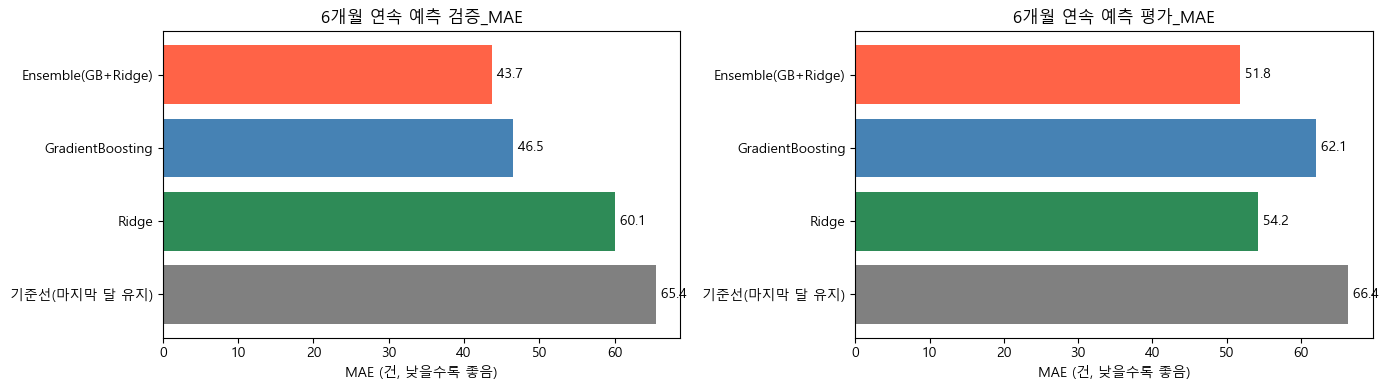

In [18]:
gb, rd = ENSEMBLE_MEMBERS
pair = valid_recs[gb][['ds', 'District', target, '예측']].merge(
    valid_recs[rd][['ds', 'District', '예측']], on=['ds', 'District'], suffixes=('_gb', '_rd'))
err_corr = (pair['예측_gb'] - pair[target]).corr(pair['예측_rd'] - pair[target])
print(f'검증 6개월 오차 상관 ({gb} vs {rd}) : {err_corr:.3f}')

ens_models = [ENSEMBLE_NAME, gb, rd, '기준선(마지막 달 유지)']
ens_cmp = detail[(detail['모델'].isin(ens_models)) & (detail['방식'] == '6개월')]
ens_cmp = ens_cmp.pivot_table(index='모델', columns='구간', values=['정확도(%)', 'MAE'])
ens_cmp.columns = [f'{p}_{m}' for m, p in ens_cmp.columns]
ens_cmp = ens_cmp.loc[ens_models, ['검증_정확도(%)', '평가_정확도(%)', '검증_MAE', '평가_MAE']]
ens_cmp.round(3).to_csv(RESULT_DIR / 'transport_ensemble_compare.csv', encoding='utf-8-sig')
display(ens_cmp.round(2))

v_ens = ens_cmp.loc[ENSEMBLE_NAME, '검증_정확도(%)']
v_members = ens_cmp.loc[[gb, rd], '검증_정확도(%)']
if v_ens > v_members.max():
    print(f'→ 앙상블 효과 있음 : 검증 정확도가 두 모델보다 {v_ens - v_members.max():+.3f}%p 높음')
else:
    print(f'→ 앙상블 효과 없음 : 검증 정확도가 더 좋은 구성 모델보다 {v_ens - v_members.max():+.3f}%p')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['tomato', 'steelblue', 'seagreen', 'gray']
for ax, col in zip(axes, ['검증_MAE', '평가_MAE']):
    ax.barh(ens_cmp.index, ens_cmp[col], color=colors)
    for i, v in enumerate(ens_cmp[col]):
        ax.text(v, i, f' {v:.1f}', va='center')
    ax.invert_yaxis()
    ax.set_xlabel('MAE (건, 낮을수록 좋음)')
    ax.set_title(f'6개월 연속 예측 {col}')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_ensemble_compare.png', bbox_inches='tight')
plt.show()

## 4-3. 시각화 ① 모델 비교 · DNN 학습 곡선
- 왼쪽 = 고르는 데 쓴 점수(검증), 오른쪽 = 보고용 점수(평가)

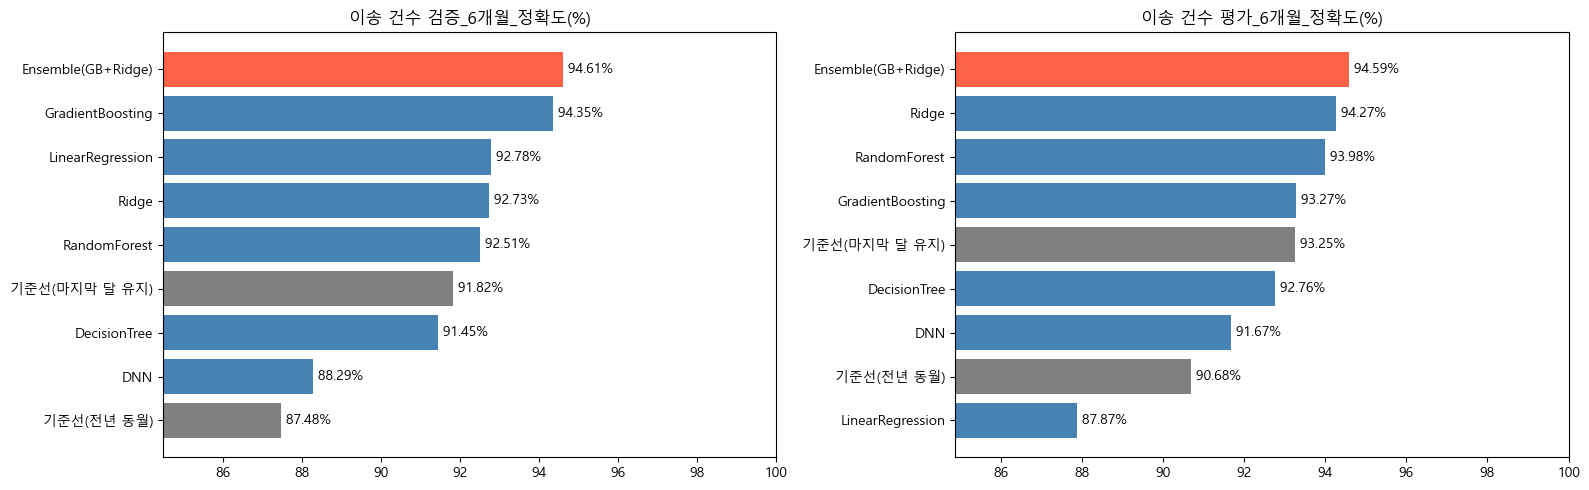

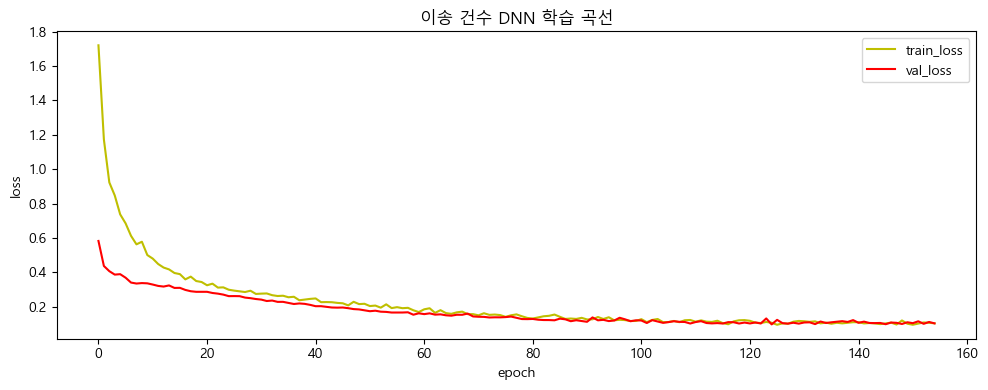

In [19]:
plot_scores(score_df, ['검증_6개월_정확도(%)', '평가_6개월_정확도(%)'], best_name,
            '이송 건수', RESULT_DIR / 'transport_model_scores.png')

if 'DNN' in bundles:
    plot_history(bundles['DNN']['history'], '이송 건수 DNN 학습 곡선', RESULT_DIR / 'transport_dnn_history.png')

## 4-4. 시각화 ② 평가 기간 결과
- 산점도 : 대각선(y=x)에 가까울수록 정확
- 자치구별 정확도 : 어느 구가 잘 맞았는지 비교
- 추이 그래프 : 파란 실선 = 실제, 빨간 점선 = 예측 (`TOP_N`으로 구 수 조정)

,지역구명,행수,실제평균,예측평균,MAE,정확도(%)
0,양천구,6,1192.17,1073.67,118.50,90.07
1,금천구,6,609.50,556.00,53.50,91.31
2,동대문구,6,986.00,904.50,82.50,91.76
3,용산구,6,630.50,581.33,49.17,92.24
4,동작구,6,710.33,657.50,53.83,92.66
5,구로구,6,1263.83,1174.83,89.00,92.99
6,성북구,6,962.00,904.67,68.00,93.03
7,성동구,6,631.50,597.33,44.17,93.07
8,서초구,6,1083.17,1008.17,75.00,93.11
9,강남구,6,1339.50,1267.67,85.83,93.80


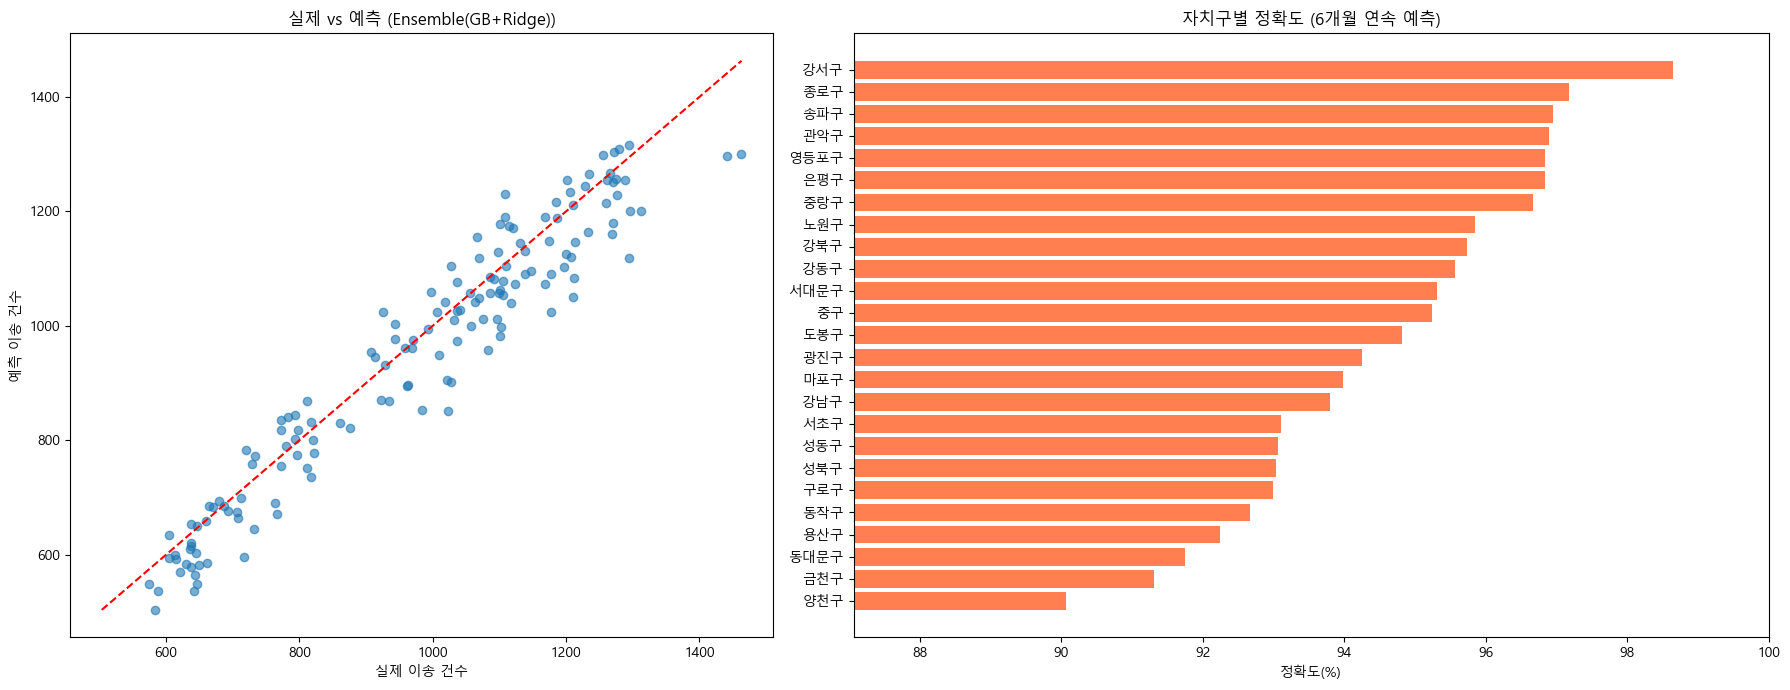

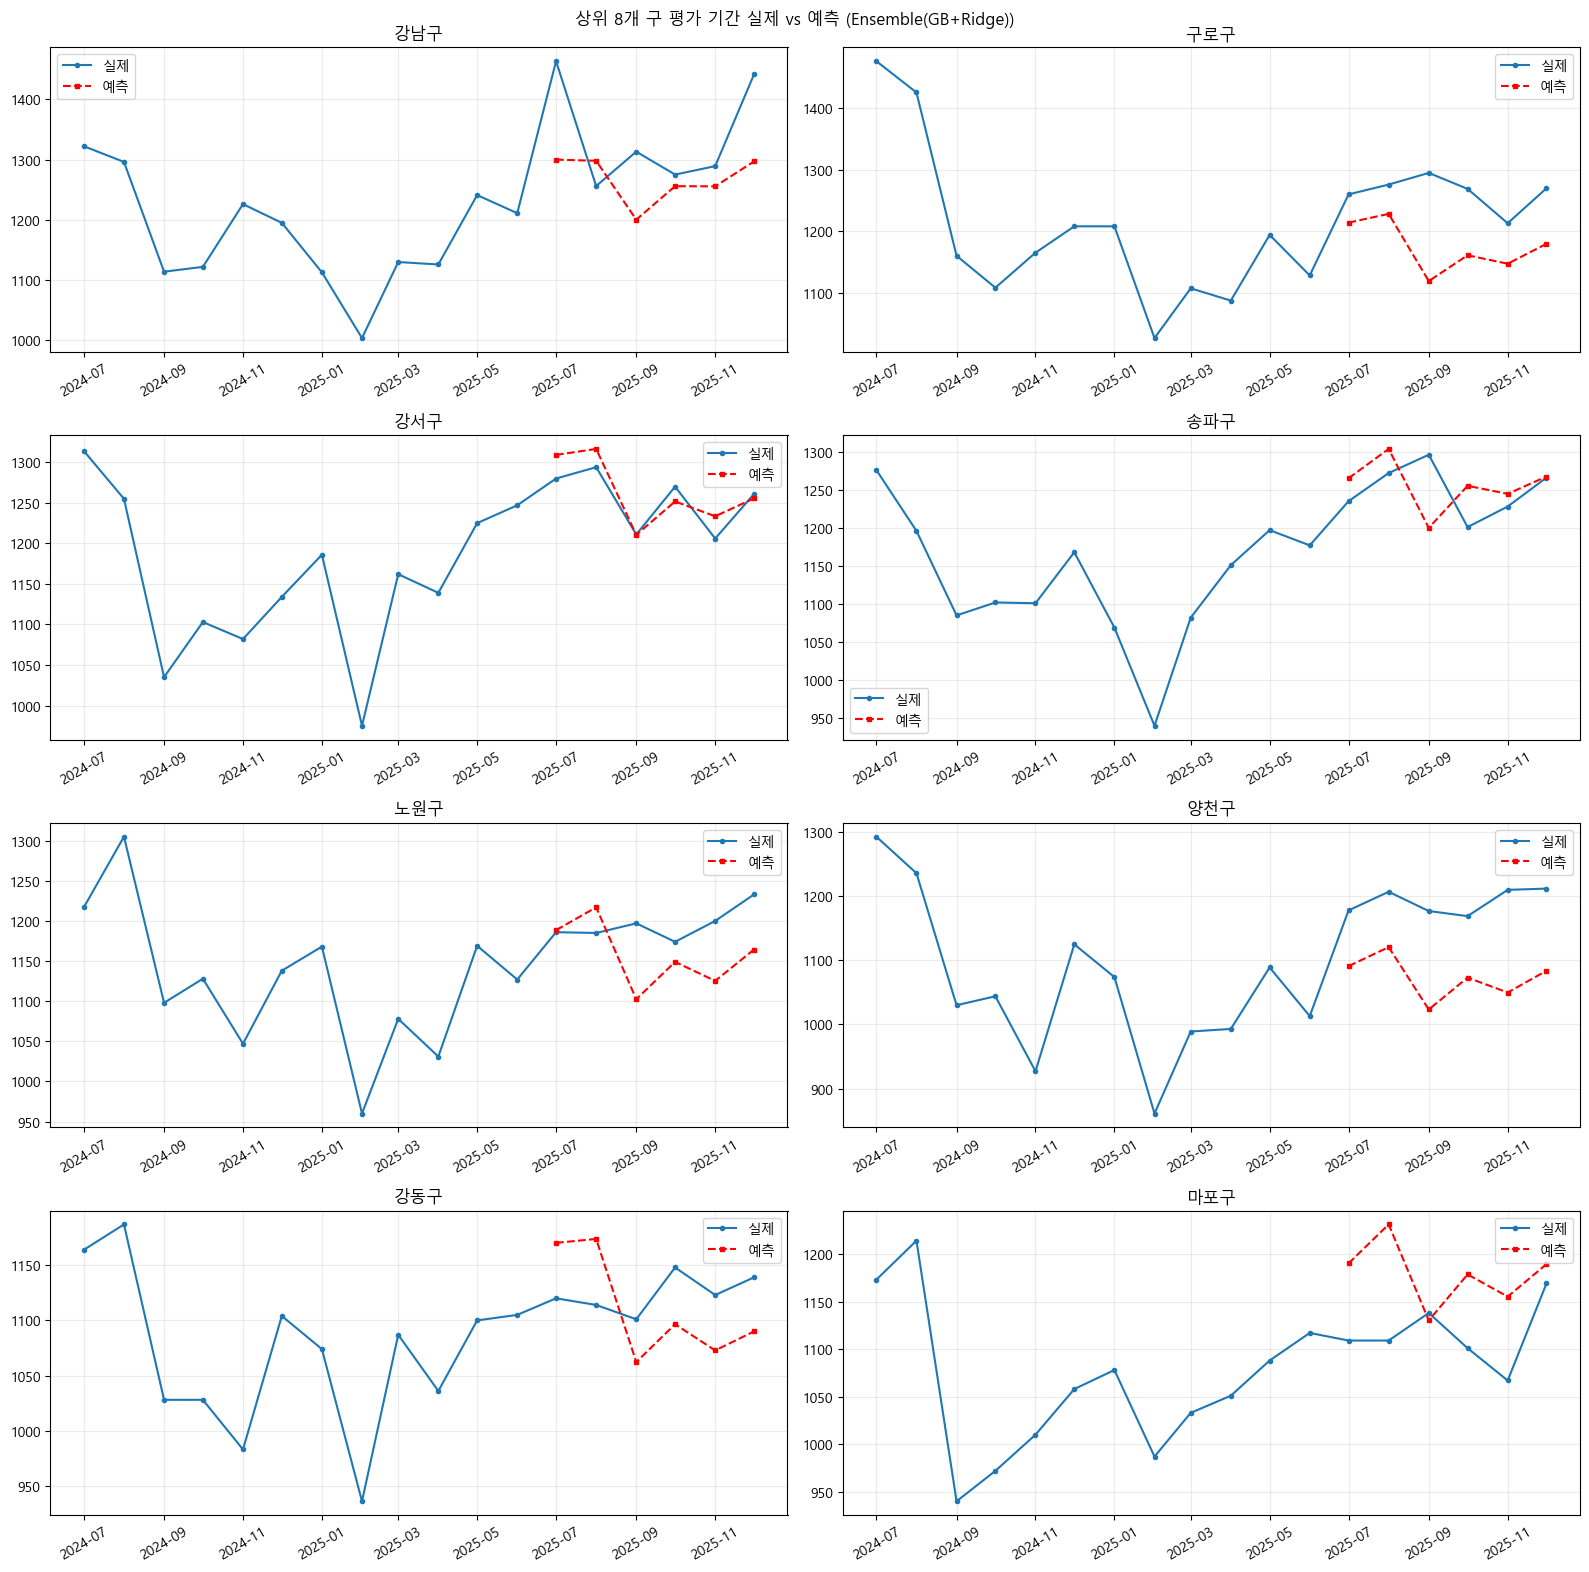

In [31]:
test_result = pd.DataFrame({
    '날짜': best_rec['ds'].dt.strftime('%Y-%m'),
    '지역구명': best_rec['District'],
    '실제_이송건수': best_rec[target].values,
    '예측_이송건수': best_rec['예측'].round(0),
})
test_result = add_error_rate(test_result, '실제_이송건수', '예측_이송건수')
test_result.to_csv(RESULT_DIR / 'transport_test_predictions.csv', index=False, encoding='utf-8-sig')

gu_score = district_scores(test_result, '실제_이송건수', '예측_이송건수')
gu_score.round(2).to_csv(RESULT_DIR / 'transport_test_scores_by_gu.csv', index=False, encoding='utf-8-sig')
display(gu_score.round(2))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1.3]})
axes[0].scatter(best_rec[target], best_rec['예측'], alpha=0.6)
lim = [best_rec[[target, '예측']].min().min(), best_rec[[target, '예측']].max().max()]
axes[0].plot(lim, lim, 'r--')
axes[0].set_xlabel('실제 이송 건수')
axes[0].set_ylabel('예측 이송 건수')
axes[0].set_title(f'실제 vs 예측 ({best_name})')
axes[1].barh(gu_score['지역구명'], gu_score['정확도(%)'], color='coral')
axes[1].set_xlim(gu_score['정확도(%)'].min() - 3, 100)
axes[1].set_xlabel('정확도(%)')
axes[1].set_title('자치구별 정확도 (6개월 연속 예측)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_test_result.png')
plt.show()

top_gu = test_result.groupby('지역구명')['실제_이송건수'].mean().nlargest(TOP_N).index.tolist()
real = full.loc[full['ds'] >= test_start - pd.DateOffset(months=12), ['District', 'ds', target]]
real.columns = ['지역구명', '날짜', '값']
pred = best_rec[['District', 'ds', '예측']].copy()
pred.columns = ['지역구명', '날짜', '값']
plot_top_trend(real, pred, top_gu, f'상위 {TOP_N}개 구 평가 기간 실제 vs 예측 ({best_name})',
               RESULT_DIR / 'transport_test_trend.png')

## 4-5. 특성 중요도
- 기준 모델 : 최고 모델 (학습+검증으로 학습한 것)
  - 앙상블이면 구성 모델 중 GradientBoosting
  - 트리 모델이 아니면(선형·DNN) RandomForest로 대신 표시
- 중요도 원리 : 해당 컬럼으로 나눴을 때 오차가 줄어든 양의 합 (합계 1)
- 증감량 예측을 채택했다면 : "이송 건수"가 아니라 "전월 대비 증감"을 설명하는 중요도

중요도 기준 모델 : GradientBoosting


,중요도
전월_transport_cnt,0.893
전년동월_transport_cnt,0.027
월(합계),0.026
일수,0.020
주말수,0.007
전월_동일자치구행정동간이동인구수,0.006
전월_night_pop,0.005
명절연휴일수,0.005
전월_일최대인구수,0.002
전년_인명갇힘,0.002


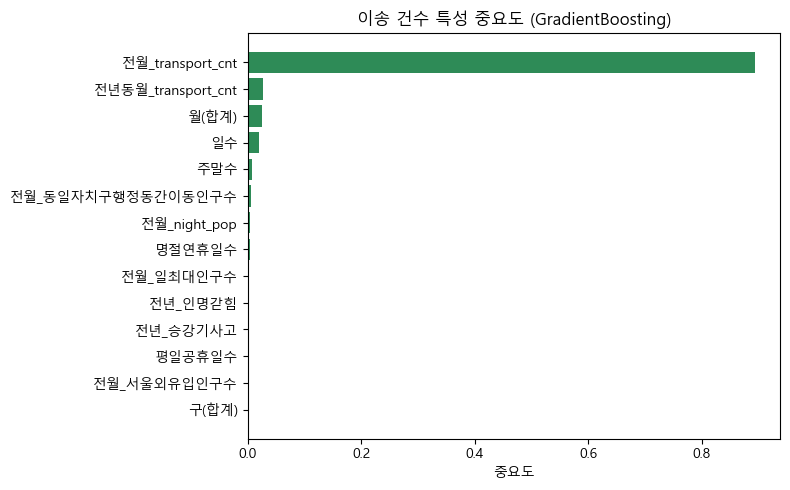

In [21]:
imp_bundle = tree_bundle(bundles[best_name], bundles['RandomForest'])
imp = group_importance(imp_bundle, ['구_', '월_'])
print('중요도 기준 모델 :', imp_bundle['name'])
display(imp.sort_values(ascending=False).round(3).to_frame('중요도'))

fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(imp, f'이송 건수 특성 중요도 ({imp_bundle["name"]})', ax)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_importance.png')
plt.show()

## 4-6. 최종 모델 저장 · 구별 미래 예측
- 최종 모델 : 최고 모델을 전체 데이터로 다시 학습 (앙상블이면 구성 모델 둘 다 다시 학습)
- 저장 후 다시 불러와서 예측 : 저장 파일 동작 확인
- 묶음에 특성 목록 · 증감량 여부가 함께 저장 → 불러온 뒤 `predict_count`로 바로 이송 건수 예측
- 입력 : `transport_future.csv` (첫 달만 실제 전월 값, 이후는 재귀 예측으로 채움)
- 결과 csv : `transport_forecast_by_gu.csv` (예측월 · 지역구명 · 예측_이송건수)

저장 모델 불러오기 확인 : True


예측월,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
지역구명,,,,,,
강남구,1349,1233,1283,1312,1400,1395
강동구,1100,997,1039,1053,1131,1122
강북구,992,904,936,948,1032,1024
강서구,1210,1088,1127,1146,1231,1215
관악구,1071,976,1027,1055,1152,1144
광진구,758,682,709,742,811,806
구로구,1217,1096,1147,1168,1257,1250
금천구,598,532,562,571,632,627
노원구,1169,1046,1084,1101,1190,1183


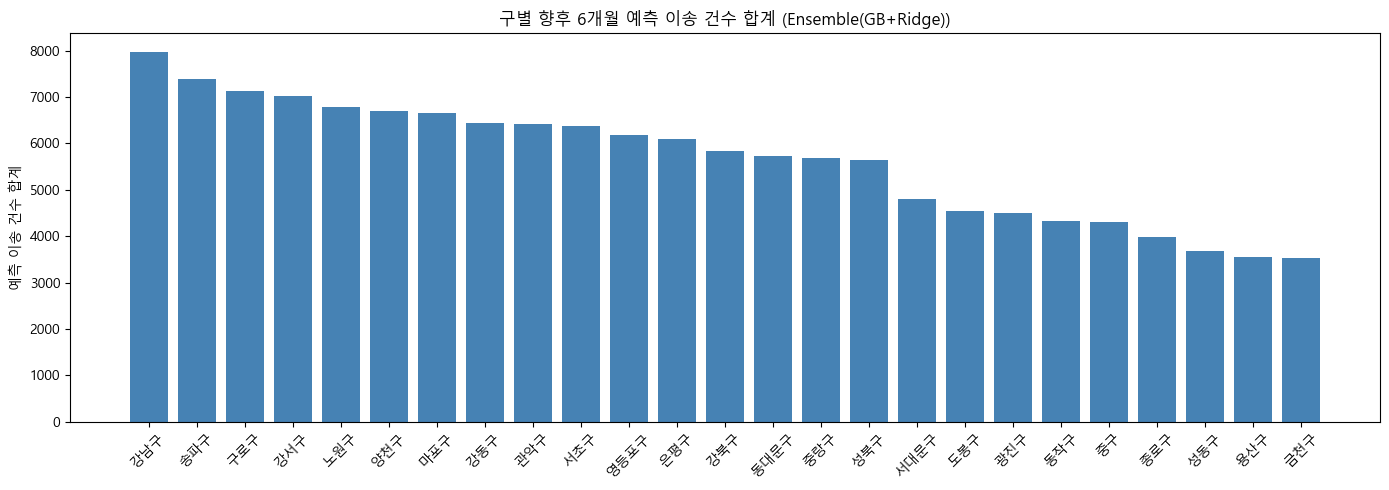

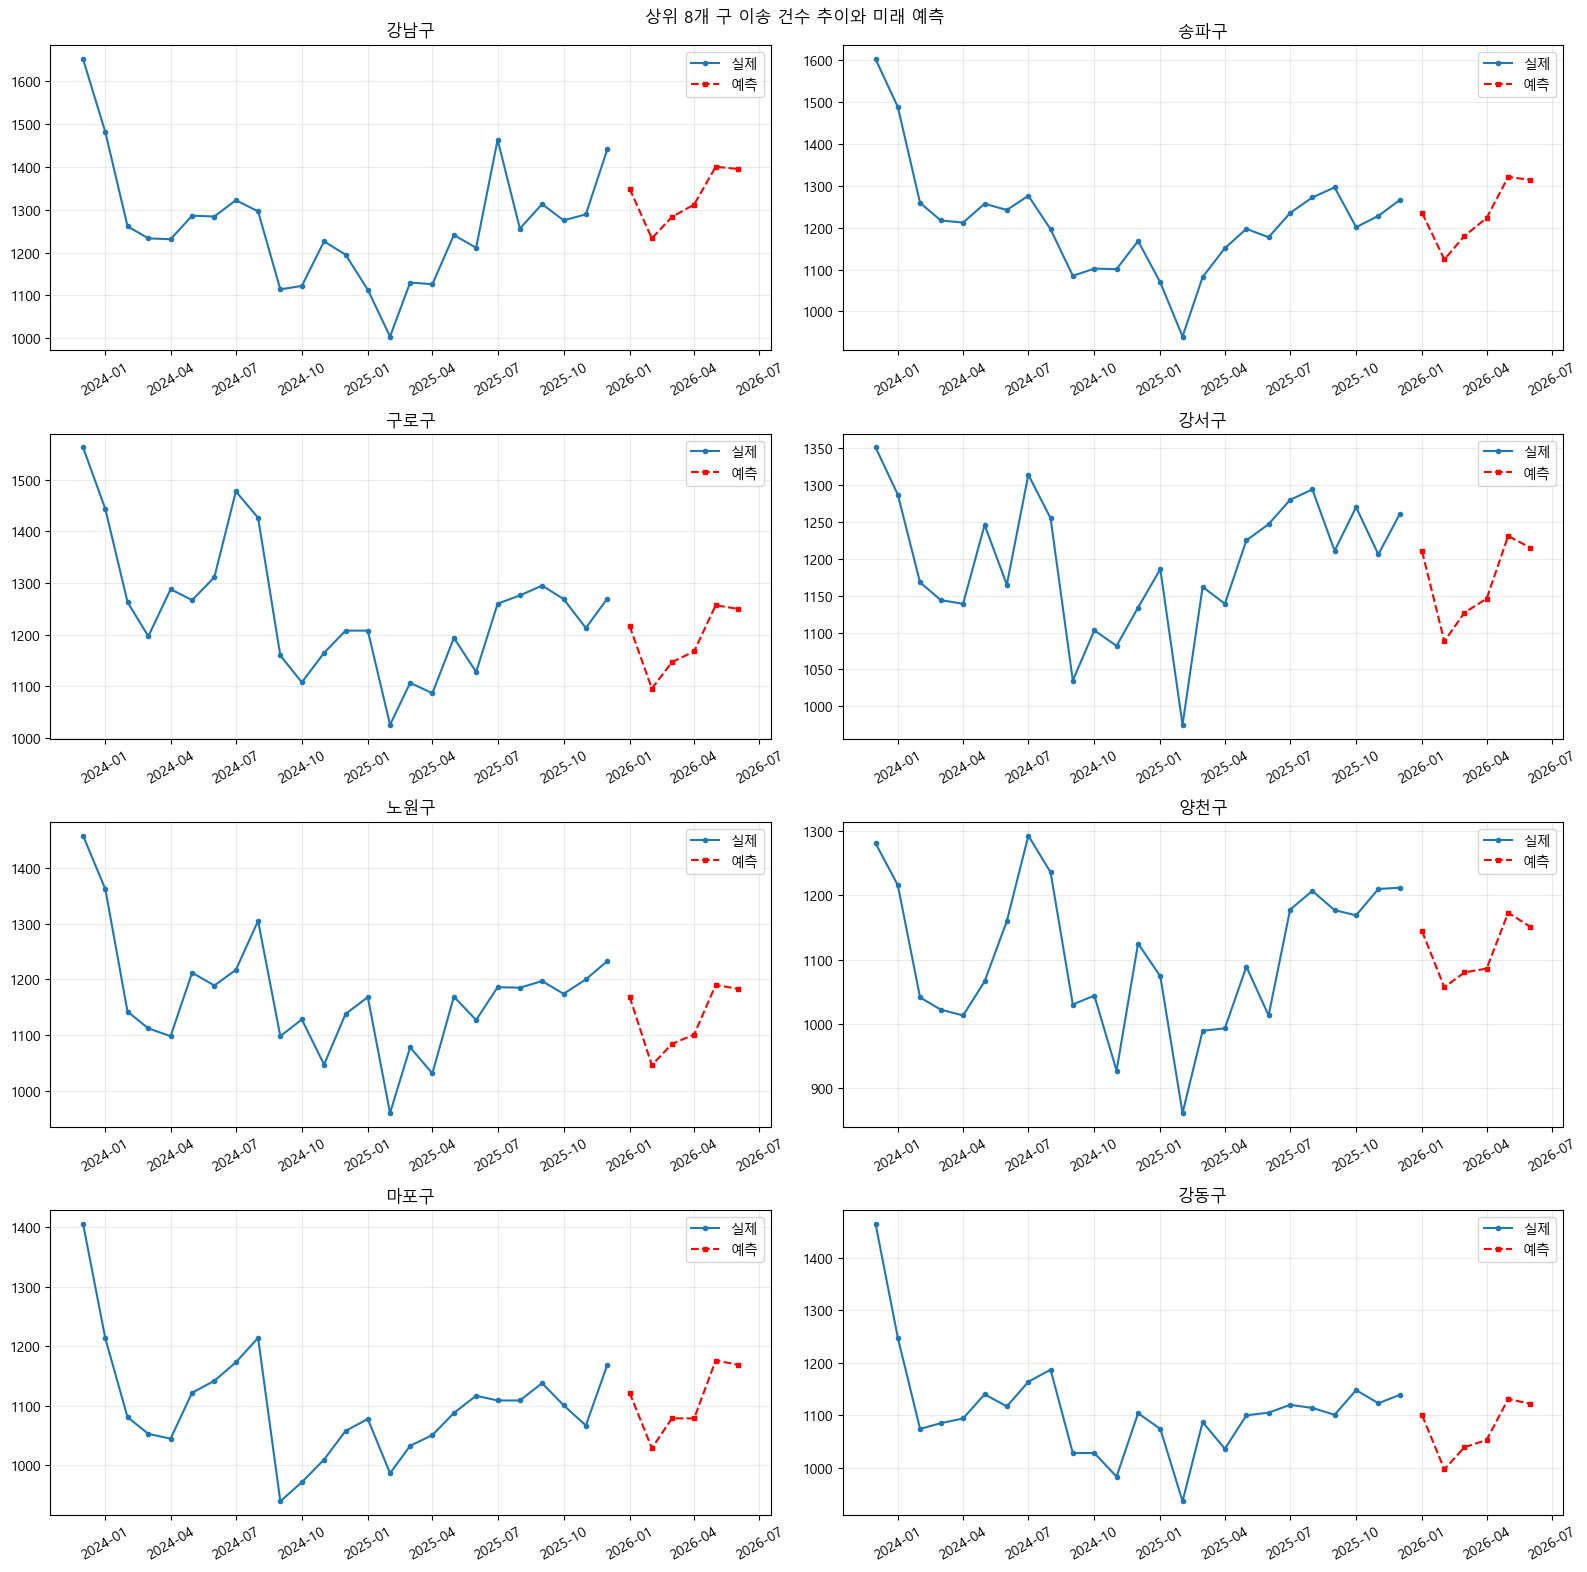

In [30]:
final = fit_transport(best_name, data, num_features, USE_DIFF_TARGET)
save_bundle(final, 'transport')

loaded = load_bundle('transport')
print('저장 모델 불러오기 확인 :',
      np.allclose(predict_count(final, data.head()), predict_count(loaded, data.head())))

fc = predict_months(loaded, future)
forecast = pd.DataFrame({
    '예측월': fc['ds'].dt.strftime('%Y-%m'),
    '지역구명': fc['District'],
    '예측_이송건수': fc['예측'].round(0).astype(int),
    '사용모델': best_name,
    '증감량예측': USE_DIFF_TARGET,
})
forecast.to_csv(RESULT_DIR / 'transport_forecast_by_gu.csv', index=False, encoding='utf-8-sig')

missing_gu = sorted(set(GU_LIST) - set(forecast['지역구명']))
if missing_gu:
    print('[주의] 입력 값이 부족해 예측하지 못한 구 :', missing_gu)
display(forecast.pivot(index='지역구명', columns='예측월', values='예측_이송건수'))

gu_total = forecast.groupby('지역구명')['예측_이송건수'].sum().sort_values(ascending=False)
plt.figure(figsize=(14, 5))
plt.bar(gu_total.index, gu_total.values, color='steelblue')
plt.xticks(rotation=45)
plt.ylabel('예측 이송 건수 합계')
plt.title(f'구별 향후 {forecast["예측월"].nunique()}개월 예측 이송 건수 합계 ({best_name})')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'transport_forecast_by_gu.png')
plt.show()

real = full.loc[full['ds'] >= full['ds'].max() - pd.DateOffset(months=24), ['District', 'ds', target]]
real.columns = ['지역구명', '날짜', '값']
pred = pd.DataFrame({'지역구명': forecast['지역구명'], '날짜': pd.to_datetime(forecast['예측월']),
                     '값': forecast['예측_이송건수']})
plot_top_trend(real, pred, gu_total.index[:TOP_N].tolist(), f'상위 {TOP_N}개 구 이송 건수 추이와 미래 예측',
               RESULT_DIR / 'transport_forecast_top.png')

---
# 5. 인구 밀집 예측 (자치구 × 일)

## 5-1. 데이터 불러오기 · 입력 만들기
- 정답 : `일최대인구수`
- 숫자 특성 : 전처리에서 `선택`된 컬럼
- 요일·월 원-핫 : 숫자(0~6)로 두면 선형 모델이 "일요일 = 월요일 × 6"처럼 잘못 해석
- **날짜순 정렬** : DNN의 `validation_split`이 마지막 20% 행(최근 기간)을 쓰도록

In [23]:
TARGET_POP = '일최대인구수'

pop = pd.read_csv(ML_DATA_DIR / 'population_selected.csv', encoding='utf-8-sig', parse_dates=['ds'])
pop_info = pd.read_csv(ML_DATA_DIR / 'features_population.csv', encoding='utf-8-sig')
pop = pop.sort_values(['ds', 'District']).reset_index(drop=True)

pop['요일'] = pop['ds'].dt.dayofweek
pop['월'] = pop['ds'].dt.month
pop['주말여부'] = (pop['요일'] >= 5).astype(int)

pop_num = pop_info.loc[pop_info['결과'] == '선택', '컬럼'].tolist()
check_features(pop_num, pop, 'population_selected.csv')


def make_pop_X(df):
    df = df.reset_index(drop=True)
    return pd.concat([df[pop_num + ['주말여부']],
                      make_dummies(df, 'District', GU_LIST, '구'),
                      make_dummies(df, '요일', range(7), '요일'),
                      make_dummies(df, '월', range(1, 13), '월')], axis=1)


X_pop = make_pop_X(pop)
y_pop = pop[TARGET_POP]
print('숫자 특성 :', pop_num)
print(X_pop.shape, '/', pop['ds'].min().date(), '~', pop['ds'].max().date())

숫자 특성 : ['7일전_일최대인구수', '전일_night_pop', '전일_일최대이동인구수', '전일_동일자치구행정동간이동인구수', '전일_pop_diff']
(75825, 50) / 2018-04-12 ~ 2026-07-31


## 5-2. 자치구별 요일 효과 확인
- 구별 평균으로 나눈 비율 (1보다 크면 평균보다 많음)
- 해석 : 업무지구는 주말 감소, 주거지역은 변화 적음

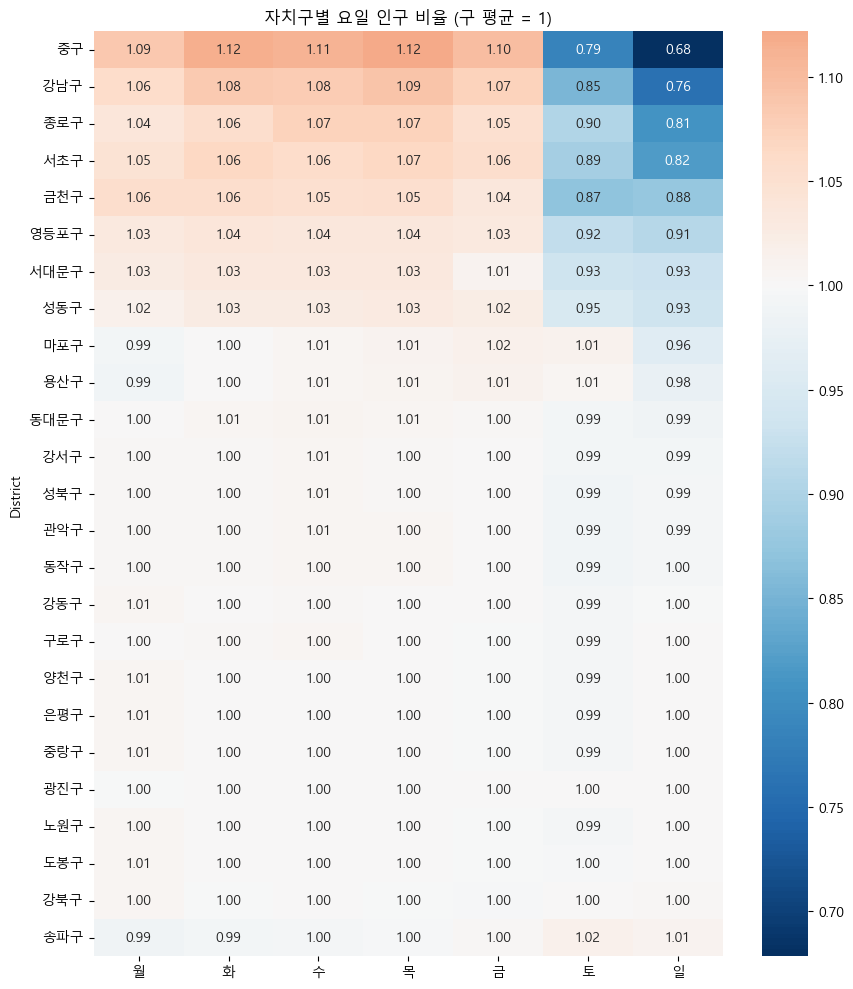

In [24]:
day_ratio = pop.pivot_table(index='District', columns='요일', values=TARGET_POP, aggfunc='mean')
day_ratio = day_ratio.div(day_ratio.mean(axis=1), axis=0)
day_ratio.columns = ['월', '화', '수', '목', '금', '토', '일']
day_ratio = day_ratio.sort_values('일')

plt.figure(figsize=(9, 10))
sns.heatmap(day_ratio, annot=True, fmt='.2f', cmap='RdBu_r', center=1)
plt.title('자치구별 요일 인구 비율 (구 평균 = 1)')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_weekday_by_gu.png')
plt.show()

## 5-3. 시간순 3단계 분할 · 모델 6종 학습
- 평가 : 마지막 1년 / 검증 : 그 앞 180일 / 학습 : 나머지
- 진행 순서는 4-2와 같음 (검증으로 고르고, 평가로 보고)
- 기준선 : 7일 전 같은 요일 값 그대로
- 데이터가 많아서(약 7만 행) 학습에 몇 분 걸릴 수 있음

학습 62200행 / 검증 4500행 (시작 2025-02-02) / 평가 9125행 (시작 2025-08-01)
LinearRegression   완료
Ridge              완료
DecisionTree       완료
RandomForest       완료
GradientBoosting   완료
DNN                완료


,모델,검증_정확도(%),평가_정확도(%),평가_R2,평가_MAE,평가_RMSE
0,RandomForest,98.589,98.163,0.986,8836.005,21081.660
1,GradientBoosting,98.356,97.970,0.986,9463.479,20994.535
2,DNN,98.010,97.759,0.984,10255.477,22328.745
3,기준선(7일 전 그대로),97.862,97.545,0.952,12015.489,38631.152
4,DecisionTree,97.855,97.479,0.978,11684.694,26195.496
5,Ridge,97.337,97.112,0.969,14036.455,30769.442
6,LinearRegression,97.335,97.110,0.969,14041.460,30769.501



최고 모델 (검증 기준) : RandomForest


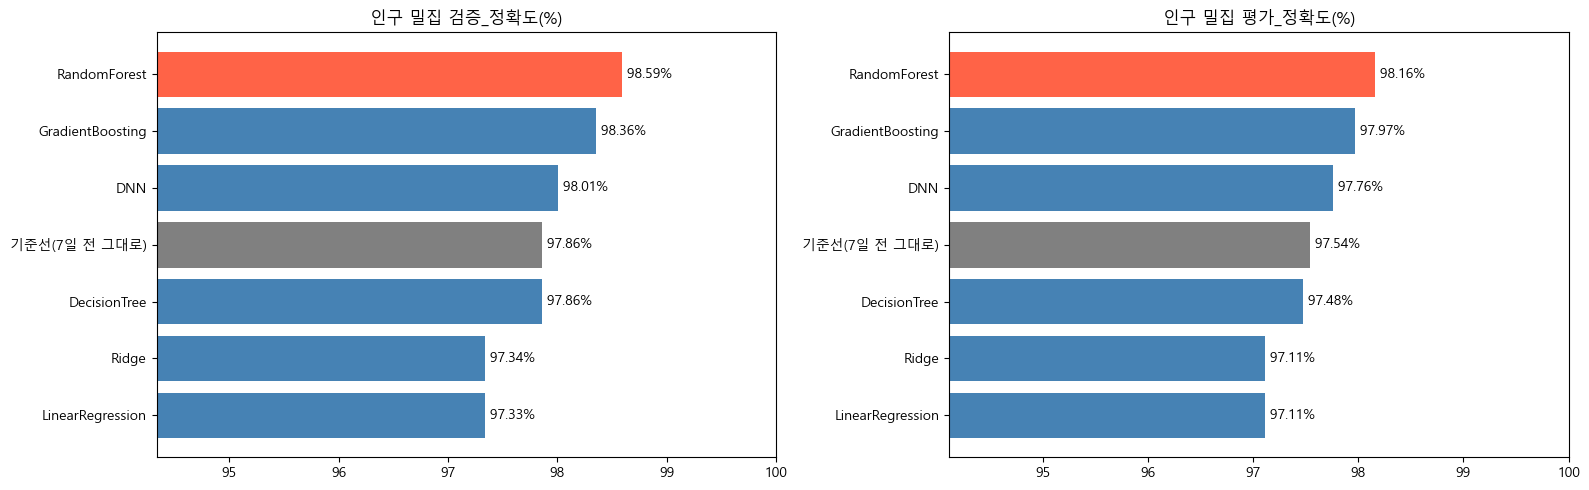

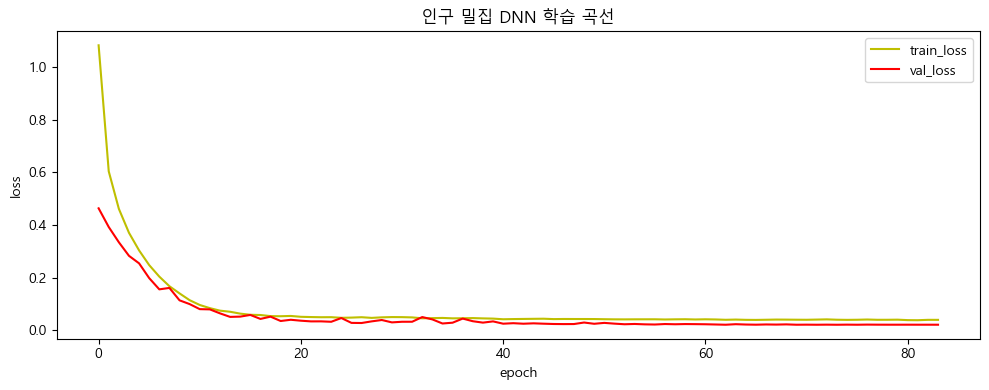

In [25]:
test_start_pop = pop['ds'].max() - pd.Timedelta(days=POP_TEST_DAYS - 1)
valid_start_pop = test_start_pop - pd.Timedelta(days=POP_VALID_DAYS)

tr = pop['ds'] < valid_start_pop
va = (pop['ds'] >= valid_start_pop) & (pop['ds'] < test_start_pop)
tv = pop['ds'] < test_start_pop
te = pop['ds'] >= test_start_pop
print(f'학습 {tr.sum()}행 / 검증 {va.sum()}행 (시작 {valid_start_pop.date()}) / 평가 {te.sum()}행 (시작 {test_start_pop.date()})')

pop_scores = []
pop_bundles = {}
pop_preds = {}
for name in MODEL_NAMES:
    b_train = fit_model(name, X_pop[tr], y_pop[tr], 'population')
    v = evaluate(y_pop[va], predict(b_train, X_pop[va]))

    b_tv = fit_model(name, X_pop[tv], y_pop[tv], 'population')
    pop_bundles[name] = b_tv
    pop_preds[name] = predict(b_tv, X_pop[te])
    t = evaluate(y_pop[te], pop_preds[name])

    pop_scores.append({'모델': name, '검증_정확도(%)': v['정확도(%)'], '평가_정확도(%)': t['정확도(%)'],
                       '평가_R2': t['R2'], '평가_MAE': t['MAE'], '평가_RMSE': t['RMSE']})
    print(f'{name:18s} 완료')

if '7일전_일최대인구수' in pop.columns:
    v = evaluate(y_pop[va], pop.loc[va, '7일전_일최대인구수'])
    t = evaluate(y_pop[te], pop.loc[te, '7일전_일최대인구수'])
    pop_scores.append({'모델': '기준선(7일 전 그대로)', '검증_정확도(%)': v['정확도(%)'],
                       '평가_정확도(%)': t['정확도(%)'], '평가_R2': t['R2'], '평가_MAE': t['MAE'],
                       '평가_RMSE': t['RMSE']})

pop_score_df = pd.DataFrame(pop_scores).sort_values('검증_정확도(%)', ascending=False).reset_index(drop=True)
pop_score_df.to_csv(RESULT_DIR / 'population_model_scores.csv', index=False, encoding='utf-8-sig')
display(pop_score_df.round(3))

pop_best = pop_score_df[pop_score_df['모델'].isin(MODEL_NAMES)].iloc[0]['모델']
pop_best_pred = pop_preds[pop_best]
print('\n최고 모델 (검증 기준) :', pop_best)

plot_scores(pop_score_df, ['검증_정확도(%)', '평가_정확도(%)'], pop_best,
            '인구 밀집', RESULT_DIR / 'population_model_scores.png')
if 'DNN' in pop_bundles:
    plot_history(pop_bundles['DNN']['history'], '인구 밀집 DNN 학습 곡선', RESULT_DIR / 'population_dnn_history.png')

## 5-4. 평가 기간 결과
- 결과 csv : `population_test_predictions.csv` · `population_test_scores_by_gu.csv` (지역구명 포함)
- 오차가 큰 날 확인 : 공휴일·명절이 많으면 공휴일 컬럼 추가 검토

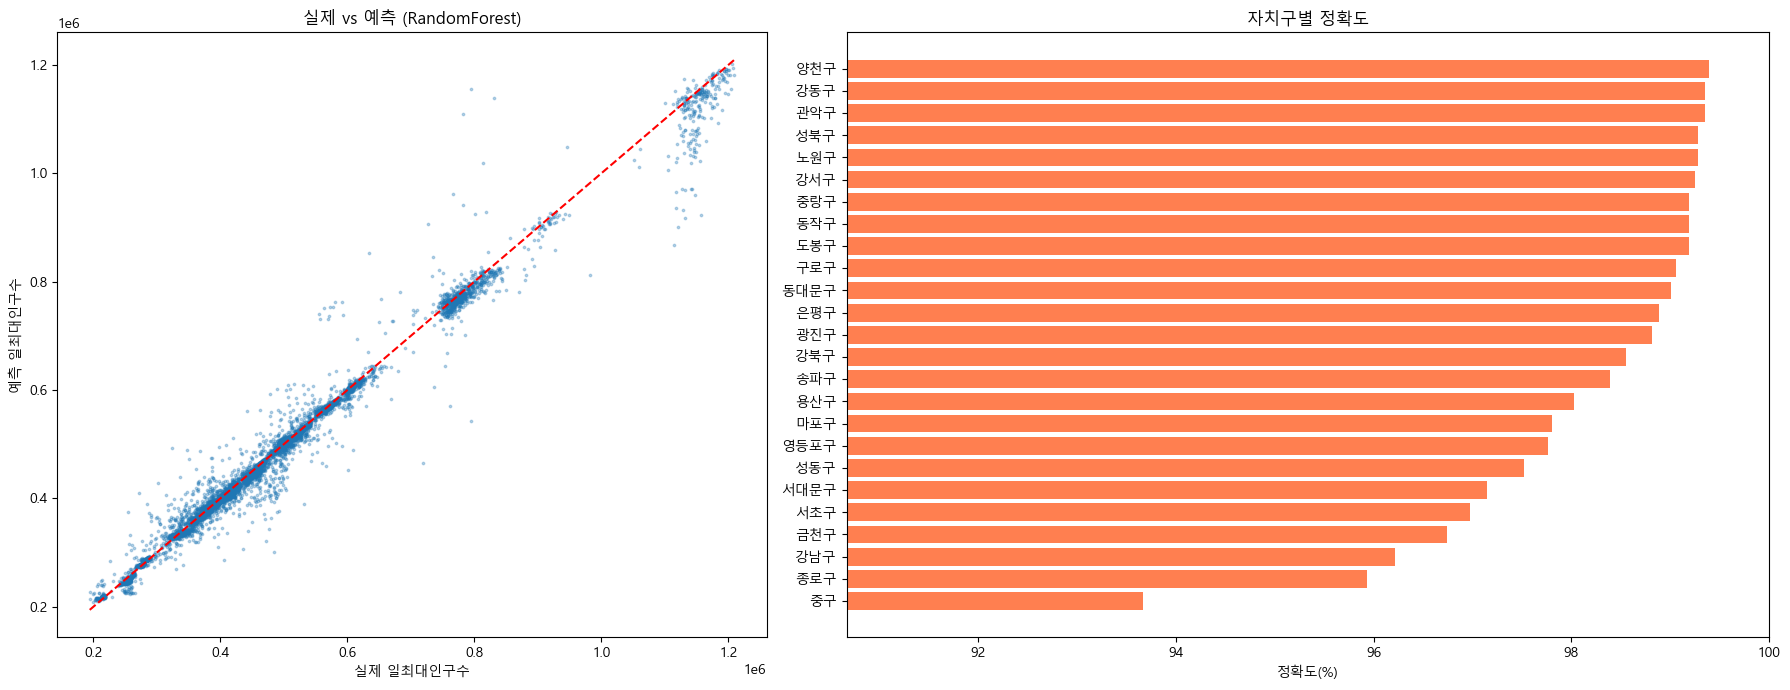

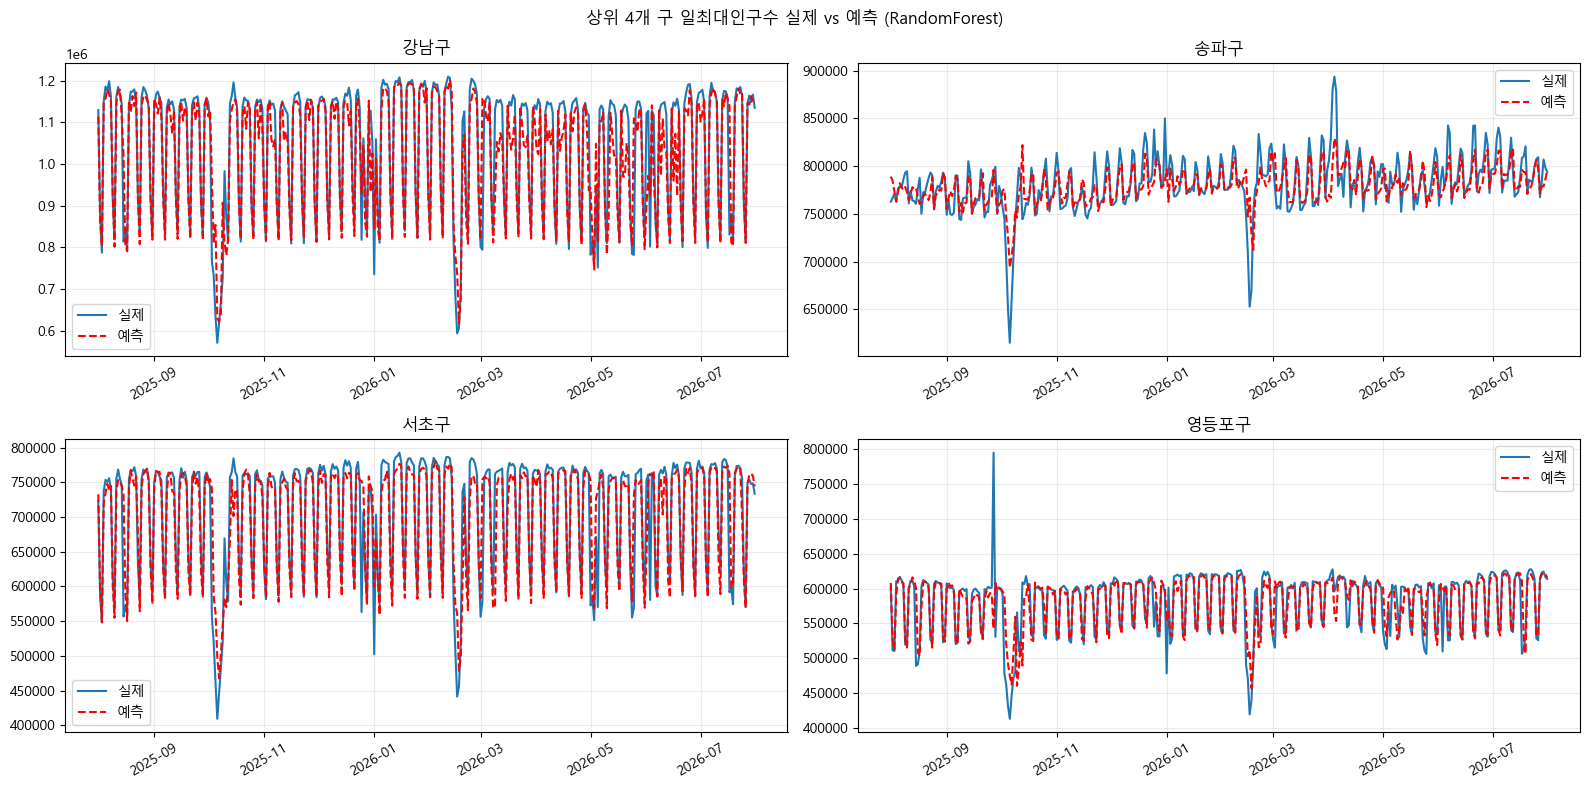

오차율 상위 10일 (서울 평균)


,평균 오차율(%)
날짜,
2025-10-06,13.07
2026-02-16,12.36
2025-10-15,12.06
2025-10-05,11.31
2025-10-03,9.19
2025-10-04,9.02
2026-01-01,8.24
2026-03-02,8.02
2026-06-03,7.97


In [26]:
pop_result = pd.DataFrame({
    '날짜': pop.loc[te, 'ds'].dt.strftime('%Y-%m-%d').values,
    '지역구명': pop.loc[te, 'District'].values,
    '실제_일최대인구수': y_pop[te].values.round(0),
    '예측_일최대인구수': pop_best_pred.round(0),
})
pop_result = add_error_rate(pop_result, '실제_일최대인구수', '예측_일최대인구수')
pop_result.to_csv(RESULT_DIR / 'population_test_predictions.csv', index=False, encoding='utf-8-sig')

pop_gu_score = district_scores(pop_result, '실제_일최대인구수', '예측_일최대인구수')
pop_gu_score.round(2).to_csv(RESULT_DIR / 'population_test_scores_by_gu.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1.3]})
axes[0].scatter(y_pop[te], pop_best_pred, s=3, alpha=0.3)
lim = [y_pop[te].min(), y_pop[te].max()]
axes[0].plot(lim, lim, 'r--')
axes[0].set_xlabel('실제 일최대인구수')
axes[0].set_ylabel('예측 일최대인구수')
axes[0].set_title(f'실제 vs 예측 ({pop_best})')
axes[1].barh(pop_gu_score['지역구명'], pop_gu_score['정확도(%)'], color='coral')
axes[1].set_xlim(pop_gu_score['정확도(%)'].min() - 3, 100)
axes[1].set_xlabel('정확도(%)')
axes[1].set_title('자치구별 정확도')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_test_result.png')
plt.show()

top_gu = pop_result.groupby('지역구명')['실제_일최대인구수'].mean().nlargest(TOP_N).index.tolist()
real = pd.DataFrame({'지역구명': pop_result['지역구명'], '날짜': pd.to_datetime(pop_result['날짜']),
                     '값': pop_result['실제_일최대인구수']})
pred = real.assign(값=pop_result['예측_일최대인구수'])
plot_top_trend(real, pred, top_gu, f'상위 {TOP_N}개 구 일최대인구수 실제 vs 예측 ({pop_best})',
               RESULT_DIR / 'population_trend.png', marker=None)

print('오차율 상위 10일 (서울 평균)')
display(pop_result.groupby('날짜')['오차율(%)'].mean().nlargest(10).round(2).to_frame('평균 오차율(%)'))

## 5-5. 특성 중요도 · 최종 모델 저장
- 원-핫 컬럼 합산 : `구_`, `요일_`, `월_`
- 최종 모델 : 전체 기간으로 다시 학습 후 저장, 다시 불러와 동작 확인

,중요도
7일전_일최대인구수,0.960
전일_night_pop,0.014
전일_pop_diff,0.011
전일_일최대이동인구수,0.004
구(합계),0.004
전일_동일자치구행정동간이동인구수,0.003
요일(합계),0.003
주말여부,0.002
월(합계),0.001


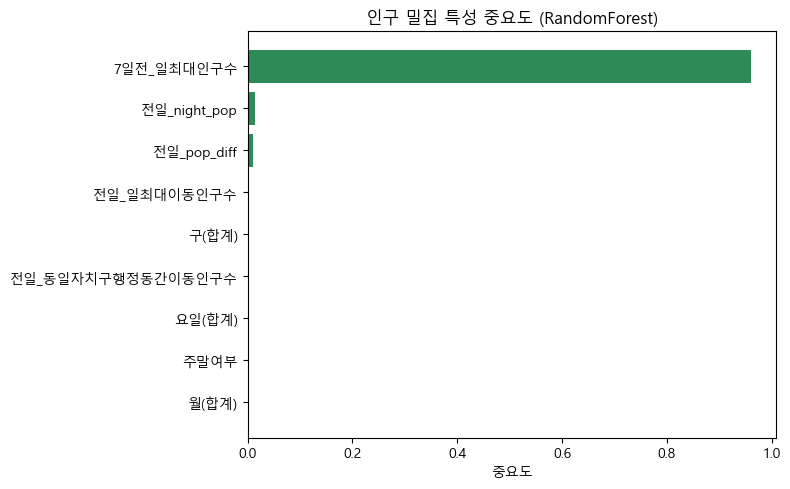

저장 모델 불러오기 확인 : True


In [27]:
imp = group_importance(pop_bundles['RandomForest'], ['구_', '요일_', '월_'])
display(imp.sort_values(ascending=False).round(3).to_frame('중요도'))

fig, ax = plt.subplots(figsize=(8, 5))
plot_importance(imp, '인구 밀집 특성 중요도 (RandomForest)', ax)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'population_importance.png')
plt.show()

pop_final = fit_model(pop_best, X_pop, y_pop, 'population')
save_bundle(pop_final, 'population')
pop_loaded = load_bundle('population')
print('저장 모델 불러오기 확인 :',
      np.allclose(predict(pop_final, X_pop.head()), predict(pop_loaded, X_pop.head())))

---
# 6. 결과 요약 (자동 출력)
- 숫자는 실행 결과에서 바로 가져옴 → 데이터가 바뀌어도 그대로 사용 가능

In [28]:
c = rel_corr.loc[KEY_POP]
set_valid = cmp_score[cmp_score['모델'] != '-'].pivot(index='특성조합', columns='모델', values='검증_정확도(%)')

print(f'[연관성] 대표 인구 : {KEY_POP}')
print(f'  자치구 간 상관 {c["자치구간"]:.2f} vs 자치구 내 상관 {c["자치구내"]:.2f}')
print(f'  인구 1만명당 이송률 최고/최저 {rate_ratio:.1f}배')
print(f'  계절 성분 상관 평균 {decomp_corr["계절_상관"].mean():.2f} / 추세 성분 상관 평균 {decomp_corr["추세_상관"].mean():.2f}')
print('\n[특성 조합별 검증 정확도(%)]')
display(set_valid.round(2))
print(f'  E - D = {pop_gain:+.3f}%p → 메인 모델 인구 특성 사용 : {USE_POP}')

print('\n[정확도 개선 실험] 설정별 최고 검증 6개월 정확도(%)')
display(best_by_set.round(3).to_frame('정확도(%)'))
print(f'  채택 설정 : {best_set} (달력 특성 {USE_CALENDAR}, 증감량 예측 {USE_DIFF_TARGET})')

print('\n[이송 건수] 최고 모델 :', best_name)
display(score_df.round(2))
print(f'\n[앙상블] 오차 상관 {err_corr:.3f}')
display(ens_cmp.round(2))
print('\n[인구 밀집] 최고 모델 :', pop_best)
display(pop_score_df.round(2))

print('\n[결과 폴더] ->', RESULT_DIR)

[연관성] 대표 인구 : night_pop
  자치구 간 상관 0.80 vs 자치구 내 상관 0.23
  인구 1만명당 이송률 최고/최저 1.9배
  계절 성분 상관 평균 -0.40 / 추세 성분 상관 평균 0.17

[특성 조합별 검증 정확도(%)]


모델,GradientBoosting,LinearRegression,RandomForest
특성조합,,,
A_계절,82.96,84.39,80.68
B_계절+인구,87.21,83.37,85.83
C_계절+인구+이송률,88.03,83.29,87.40
D_계절+이송이력,94.96,94.34,94.17
E_전체,94.79,94.45,94.10


  E - D = -0.177%p → 메인 모델 인구 특성 사용 : False

[정확도 개선 실험] 설정별 최고 검증 6개월 정확도(%)


,정확도(%)
설정,
기본,93.885
달력,94.612
증감량,94.226
달력+증감량,94.470


  채택 설정 : 달력 (달력 특성 True, 증감량 예측 False)

[이송 건수] 최고 모델 : Ensemble(GB+Ridge)


...


[앙상블] 오차 상관 0.500


,검증_정확도(%),평가_정확도(%),검증_MAE,평가_MAE
모델,,,,
Ensemble(GB+Ridge),94.61,94.59,43.66,51.76
GradientBoosting,94.35,93.27,46.52,62.06
Ridge,92.73,94.27,60.11,54.20
기준선(마지막 달 유지),91.82,93.25,65.45,66.35



[인구 밀집] 최고 모델 : RandomForest


,모델,검증_정확도(%),평가_정확도(%),평가_R2,평가_MAE,평가_RMSE
0,RandomForest,98.59,98.16,0.99,8836.01,21081.66
1,GradientBoosting,98.36,97.97,0.99,9463.48,20994.54
2,DNN,98.01,97.76,0.98,10255.48,22328.75
3,기준선(7일 전 그대로),97.86,97.54,0.95,12015.49,38631.15
4,DecisionTree,97.86,97.48,0.98,11684.69,26195.50
5,Ridge,97.34,97.11,0.97,14036.46,30769.44
6,LinearRegression,97.33,97.11,0.97,14041.46,30769.50



[결과 폴더] -> C:\ai\source\09_Project\cheolhyeon_jo\ml_result


최종 모델은 **GradientBoosting + Ridge 앙상블(달력 특성 포함)** 로, 향후 6개월 연속 예측에서 **평가 정확도 94.6%** 를 기록했습니다.



**정확도를 높이기 위해 시도한 것**
- 효과가 컸던 시도 : 앙상블(평가 MAE 20% 감소), 달력 특성(검증 +0.73%p)
- 최종 성과 : 6개월 예측 평가 정확도 94.6%, 기준선 대비 MAE 22% 감소
- 제외 : 증감량 예측(달력보다 낮음), 달력 특성 및 증감량 동시 적용(급락), PCA·RFE·순서형 모델(구조·데이터 부적합)